# Reproducing the results - SU(2) x Sim(2) on MNIST

**Reviewer verification notebook.** No architecture is defined here and nothing
is retrained. Model weights are loaded from the repository and the notebook
replays **the full evaluation protocol of the paper**.

---

## What is reproduced

| Phase | Content | Output |
|---|---|---|
| **A** | Clean accuracy, parameter counts, latency | `table1_clean_accuracy.csv` |
| **B** | Architectural equivariance (random **and** trained weights) | `equivariance_*.csv/png` |
| **C** | Visual control panels for the transformations | `transforms_*.png` |
| **D** | Robustness sweeps: phi / psi1 / scale / projective / combo / Haar SU(2) | `rob_sweep_*.csv`, `robustness_curves.png` |
| **E** | Training curves (replotted, not recomputed) | `training_curves.png` |
| **F** | Summary table + `.zip` archive | `reviewer_summary.csv` |

## What is **not** in this notebook

- the training loop, optimiser and scheduler;
- the MNIST training split - only the test set is downloaded.

The architectures themselves live in the training notebook at the repository
root and are instantiated through `repro_models.py`, so the code that loads the
weights cannot drift from the code that produced the paper's numbers.

## How to run

1. Run the configuration cell (set `REPO_URL`).
2. `Runtime -> Run all`.
3. Keep `RUN_MODE = "quick"` for a first check (~5 min on a T4), then switch to
   `"full"` for the exact protocol of the paper (~35-50 min).

> **Integrity.** Every checkpoint is verified by SHA-256 against the manifest
> shipped with the repository, so any divergence between the loaded weights and
> the ones declared by the authors is reported.

> **Environment.** `torch-harmonics` publishes wheels for CPython 3.10-3.12
> only. On a Python 3.13 runtime the setup cell builds version 0.9.1 from
> source; this takes a few minutes and is required for `SU2Stereo`.

---

## 0 - Configuration

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION  -  the only cell you need to edit
# ══════════════════════════════════════════════════════════════════════════════

# -- Repository holding the pre-trained weights -------------------------------
REPO_URL    = "https://github.com/reviewer-aaai/AAAI.git"   # <- fill in
REPO_DIR    = "su2_sim2_repro"
CKPT_SUBDIR = "checkpoints/mnist_v10"                 # weights folder inside the repo

# -- Outputs ------------------------------------------------------------------
OUT_DIR = "./reviewer_outputs"

# -- Run mode -----------------------------------------------------------------
#   "full"  : exact protocol of the paper (10,000 test images, all sweep
#             points).                                   T4 GPU ~ 35-50 min
#   "quick" : subsampled, roughly 8x faster, same trends. Use it for a first
#             check.                                     T4 GPU ~ 5 min
RUN_MODE = "full"        # "quick" | "full"

# -- Evaluation protocol ------------------------------------------------------
#   "paper"         : validation transform identical to training
#                     (Resize 64 + RandomCrop 64 pad 6), seeded so that the
#                     numbers are reproducible from one run to the next.
#   "deterministic" : Resize 64 + reflect padding + CenterCrop, no randomness.
#                     Shifts accuracies by a few tenths of a point.
EVAL_TRANSFORM = "paper"

SEED = 42

# -- Classes dropped from the sweeps (6<->9 ambiguity under rotation) ---------
EXCLUDED_CLASSES = (1, 9)

# -- Presets ------------------------------------------------------------------
PRESETS = {
    "full":  dict(n_val=None, n_phi=20, n_psi1=20, n_proj=40, n_combo=20, n_su2=32,
                  batch_size=128),
    "quick": dict(n_val=2000, n_phi=10, n_psi1=10, n_proj=12, n_combo=10, n_su2=12,
                  batch_size=256),
}
CFG = PRESETS[RUN_MODE]
print(f"Mode '{RUN_MODE}' -> {CFG}")

Mode 'full' -> {'n_val': None, 'n_phi': 20, 'n_psi1': 20, 'n_proj': 40, 'n_combo': 20, 'n_su2': 32, 'batch_size': 128}


## 1 - Setup and weight retrieval

In [2]:
# =============================================================================
#  SETUP - dependencies and repository files
# =============================================================================
import os, subprocess, sys

# -- 1. Locate the repository -------------------------------------------------
# Anonymous review: the repository is distributed as a zip, not as a git remote.
# Upload it to the Colab session (folder icon in the left sidebar), or unzip it
# next to this notebook. REPO_URL is only used if you have a clonable remote.
if not os.path.isdir(REPO_DIR):
    zips = [f for f in os.listdir('.') if f.endswith('.zip')]
    if zips:
        import zipfile
        print(f"Extracting {zips[0]} ...")
        with zipfile.ZipFile(zips[0]) as z:
            z.extractall(REPO_DIR)
    elif REPO_URL and not REPO_URL.startswith("<"):
        print(f"Cloning {REPO_URL} ...")
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
                       check=True)
    else:
        raise FileNotFoundError(
            f"'{REPO_DIR}' not found. Upload the repository zip to this Colab "
            f"session and re-run this cell, or set REPO_URL if you have a "
            f"clonable remote.")
else:
    print(f"Repository found: {REPO_DIR}")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# -- 2. Dependencies ----------------------------------------------------------
# Nothing to install. The models ship as self-contained TorchScript archives,
# so no architecture code and no geometric library (torch-harmonics, e2cnn)
# are needed. torch, torchvision, numpy, pandas, matplotlib and tqdm all ship
# with Colab.
print(f"Python {sys.version.split()[0]}")

# -- 3. Inventory -------------------------------------------------------------
ckpt_dir = os.path.join(REPO_DIR, CKPT_SUBDIR)
print(f"\n{ckpt_dir}")
if os.path.isdir(ckpt_dir):
    for f in sorted(os.listdir(ckpt_dir)):
        size = os.path.getsize(os.path.join(ckpt_dir, f)) / 1e6
        print(f"   {f:<32} {size:8.2f} MB")
else:
    print("   Folder not found - check CKPT_SUBDIR.")

Cloning https://github.com/reviewer-aaai/AAAI.git ...
Python 3.13.15

su2_sim2_repro/checkpoints/mnist_v10
   BiLogPolar.pth                       2.02 MB
   BiLogPolar.ts.pt                     2.19 MB
   BiLogPolar_random.pth                2.01 MB
   BiLogPolar_random.ts.pt              2.18 MB
   Classic.pth                          2.03 MB
   Classic.ts.pt                        2.14 MB
   Classic_random.pth                   2.03 MB
   Classic_random.ts.pt                 2.14 MB
   SU2Stereo.pth                        2.07 MB
   SU2Stereo.ts.pt                      2.67 MB
   SU2Stereo_random.pth                 2.07 MB
   SU2Stereo_random.ts.pt               2.68 MB
   Sim2Only.pth                         2.11 MB
   Sim2Only.ts.pt                       2.25 MB
   Sim2Only_random.pth                  2.11 MB
   Sim2Only_random.ts.pt                2.25 MB
   equivariance_random.json             0.01 MB
   history.csv                          0.00 MB
   manifest.json             

## 2 - Imports and constants

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  IMPORTS & CONSTANTS
#  No architecture is defined here - this notebook only runs inference.
# ══════════════════════════════════════════════════════════════════════════════
import math, os, gc, json, time, hashlib, random, zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm
from IPython.display import display, Image as IPImage
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.backends.cudnn.benchmark = True

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

seed_everything()
os.makedirs(OUT_DIR, exist_ok=True)

def show_png(path, width=1100):
    """Displays a figure already written to disk (matplotlib runs headless)."""
    if os.path.exists(path):
        display(IPImage(filename=path, width=width))
    else:
        print(f"figure not found: {path}")

# -- Palette and labels (same as in the paper) -------------------------------
MODEL_COLORS  = {"Classic": "#e15759", "Sim2Only": "#4e79a7",
                 "SU2Stereo": "#59a14f", "BiLogPolar": "#f28e2b"}
MODEL_MARKERS = {"Classic": "s", "Sim2Only": "D",
                 "SU2Stereo": "^", "BiLogPolar": "o"}
MODEL_LABELS  = {"Classic": "Classic", "Sim2Only": "Sim(2)",
                 "SU2Stereo": "SU(2) stereographic", "BiLogPolar": "Bi-LogPolar"}

print(f"device         : {device}  "
      f"({torch.cuda.get_device_name(0) if device.type=='cuda' else 'CPU'})")
print(f"torch          : {torch.__version__}")
print(f"outputs        : {os.path.abspath(OUT_DIR)}")

device         : cuda  (Tesla T4)
torch          : 2.11.0+cu128
outputs        : /content/reviewer_outputs


## 3 - Evaluation toolbox

These four cells are taken **verbatim** from the training notebook, with one documented exception: the descriptor is read from the input of the classification head, which is the same quantity for all four architectures.

In [4]:
# =============================================================================
#  TRANSFORMATIONS AND SWEEP GRIDS
#  Taken VERBATIM from the training notebook, which guarantees the reviewer
#  evaluates on exactly the same transformations as the paper.
# =============================================================================

# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORMATIONS FOR THE EQUIVARIANCE AND ROBUSTNESS TESTS
# ══════════════════════════════════════════════════════════════════════════════

def apply_rotation_2d(x, deg):
    t = math.radians(deg)
    aff = torch.tensor([[math.cos(t), -math.sin(t), 0.],
                         [math.sin(t),  math.cos(t), 0.]], device=x.device)
    aff = aff.unsqueeze(0).expand(x.shape[0], -1, -1)
    return F.grid_sample(x, F.affine_grid(aff, x.shape, align_corners=True),
                         align_corners=True, mode='bilinear', padding_mode='zeros')


def apply_mobius_phi(x, beta):
    """Radial SU(2) Mobius map: z -> (z+t)/(1-tz), t = tan(beta/2)."""
    t = math.tan(float(beta) / 2)
    lin = torch.linspace(-1, 1, x.shape[-1], device=x.device)
    gr = torch.stack(torch.meshgrid(lin, lin, indexing='xy'))
    z = torch.complex(gr[0], gr[1])
    zp = (z + t) / (1 - t * z)
    grid = torch.stack([zp.real.clamp(-1, 1), zp.imag.clamp(-1, 1)], dim=-1)
    return F.grid_sample(x, grid.unsqueeze(0).expand(x.shape[0], -1, -1, -1),
                         mode='bilinear', padding_mode='border', align_corners=True)


def apply_scale(x, scale):
    s = 1. / scale
    aff = torch.tensor([[s, 0., 0.], [0., s, 0.]], device=x.device)
    aff = aff.unsqueeze(0).expand(x.shape[0], -1, -1)
    return F.grid_sample(x, F.affine_grid(aff, x.shape, align_corners=True),
                         align_corners=True, mode='bilinear', padding_mode='zeros')


def apply_projective(x, c1=0.001, c2=0.001):
    H_mat = np.array([[1., 0., 0.], [0., 1., 0.], [c1, c2, 1.]])
    try:    H_inv = np.linalg.inv(H_mat)
    except: H_inv = np.eye(3)
    lin = torch.linspace(-1, 1, x.shape[-1], device=x.device)
    yy, xx = torch.meshgrid(lin, lin, indexing='ij')
    pts = torch.stack([xx.flatten(), yy.flatten(),
                       torch.ones(x.shape[-1] ** 2, device=x.device)])
    H_t = torch.tensor(H_inv, dtype=torch.float32, device=x.device)
    src = H_t @ pts
    w_ = src[2:3].clamp(min=1e-8)
    grid = (src[:2] / w_).T.reshape(x.shape[-1], x.shape[-1], 2)
    return F.grid_sample(x, grid.unsqueeze(0).expand(x.shape[0], -1, -1, -1),
                         mode='bilinear', padding_mode='zeros', align_corners=True)


def make_radial_images(n, size, device):
    lin = torch.linspace(-1, 1, size, device=device)
    yy, xx = torch.meshgrid(lin, lin, indexing='ij')
    r = (xx**2 + yy**2).sqrt()
    img = r.unsqueeze(0).unsqueeze(0).expand(n, 1, size, size)  # ← (N, 1, H, W)
    return img.contiguous()


# ══════════════════════════════════════════════════════════════════════════════
# GRILLES DE SWEEP (robustesse)
# ══════════════════════════════════════════════════════════════════════════════

def _mobius_grid(mat, grid_r2):
    a, b = mat[0, 0], mat[0, 1]
    z = torch.complex(grid_r2[0], grid_r2[1])
    denom = -torch.conj(b) * z + torch.conj(a)
    zp = (a * z + b) / (denom + 1e-8)
    return torch.stack([zp.real, zp.imag], dim=-1)


def _build_phi_grids_manual(phi_values, grid_r2):
    grids = []
    for phi in phi_values:
        alpha = torch.tensor(math.cos(phi / 2), dtype=torch.complex64)
        beta = torch.tensor(1j * math.sin(phi / 2), dtype=torch.complex64)
        mat = torch.tensor([[alpha, beta], [-beta.conj(), alpha.conj()]],
                           dtype=torch.complex64, device=grid_r2.device)
        a, b = mat[0, 0].conj(), mat[1, 0].conj()
        z = torch.complex(grid_r2[0], grid_r2[1])
        denom = -b.conj() * z + a.conj()
        zp = (a * z + b) / (denom + 1e-8)
        grids.append(torch.stack([zp.real, zp.imag], dim=-1))
    return torch.stack(grids)


def _build_psi1_grids(n_steps, grid_r2, phi_fixed=0., max_deg=90.):
    max_rad = math.radians(max_deg)
    psi1_vals = torch.linspace(0., max_rad, n_steps)
    phi = torch.full((n_steps,), phi_fixed)
    psi2 = torch.zeros(n_steps)
    alpha = torch.cos(phi / 2) * torch.complex(torch.cos((psi1_vals + psi2) / 2),
                                                torch.sin((psi1_vals + psi2) / 2))
    beta = 1j * torch.sin(phi / 2) * torch.complex(torch.cos((psi1_vals - psi2) / 2),
                                                    torch.sin((psi1_vals - psi2) / 2))
    mats = torch.stack([torch.stack([torch.stack([alpha, beta], -1),
                                     torch.stack([-torch.conj(beta), torch.conj(alpha)], -1)], -2)])[0]
    mats = mats.to(grid_r2.device)
    grids = torch.stack([_mobius_grid(mats[i].mH, grid_r2) for i in range(n_steps)])
    return psi1_vals.numpy(), np.degrees(psi1_vals.numpy()), grids


def _build_scale_grids(scale_values, H, W, device):
    grids = []
    for s in scale_values:
        xs = torch.linspace(-1. / s, 1. / s, W, device=device)
        ys = torch.linspace(-1. / s, 1. / s, H, device=device)
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        grids.append(torch.stack([xx, yy], dim=-1))
    return torch.stack(grids), np.array(scale_values, dtype=np.float32)


def _build_projective_grids(n_samples, H, W, device, seed=42,
                             mnist_safe=False):          # ← NOUVEAU flag
    rng = np.random.default_rng(seed)

    if mnist_safe:
        # -- Reduced amplitudes: keep the digit class intact --------------------
        thetas = rng.uniform(-math.pi / 12, math.pi / 12, n_samples)  # +/-15 deg (was +/-180)
        scales = rng.uniform(0.85, 1.15, n_samples)                    # +/-15% (was 0.3-1.7)
        shears = rng.uniform(-10., 10., n_samples)                     # +/-10 deg (was +/-45)
        txs    = rng.uniform(-0.05, 0.05, n_samples)                   # +/-5% (was +/-10%)
        tys    = rng.uniform(-0.05, 0.05, n_samples)                   # ±5%
        c1s    = rng.uniform(-0.001, 0.001, n_samples)                 # +/-0.001 (was +/-0.002)
        c2s    = rng.uniform(-0.001, 0.001, n_samples)
    else:
        # ── Amplitudes originales (STL-10) ────────────────────────────────────
        thetas = rng.uniform(-math.pi, math.pi, n_samples)
        scales = rng.uniform(0.3, 1.7, n_samples)
        shears = rng.uniform(-45., 45., n_samples)
        txs    = rng.uniform(-0.1, 0.1, n_samples)
        tys    = rng.uniform(-0.1, 0.1, n_samples)
        c1s    = rng.uniform(-0.002, 0.002, n_samples)
        c2s    = rng.uniform(-0.002, 0.002, n_samples)

    xs = torch.linspace(-1, 1, W, device=device)
    ys = torch.linspace(-1, 1, H, device=device)
    yy, xx  = torch.meshgrid(ys, xs, indexing='ij')
    pts_out = torch.stack([xx.flatten(), yy.flatten(),
                           torch.ones(H * W, device=device)])
    grids = []
    for i in range(n_samples):
        ct, st = math.cos(thetas[i]), math.sin(thetas[i])
        sh = math.tan(math.radians(shears[i]))
        R  = np.array([[ct, -st, 0.], [st,  ct, 0.], [0., 0., 1.]])
        Sh = np.array([[1., sh,  0.], [0.,  1., 0.], [0., 0., 1.]])
        S  = np.diag([scales[i], scales[i], 1.])
        P  = np.array([[1., 0., 0.], [0., 1., 0.], [c1s[i], c2s[i], 1.]])
        T  = np.array([[1., 0., txs[i]], [0., 1., tys[i]], [0., 0., 1.]])
        H_mat = T @ P @ S @ Sh @ R
        try:    H_inv = np.linalg.inv(H_mat)
        except: H_inv = np.eye(3)
        H_t = torch.tensor(H_inv, dtype=torch.float32, device=device)
        src = H_t @ pts_out
        w_  = src[2:3].clamp(min=1e-8)
        grids.append((src[:2] / w_).T.reshape(H, W, 2))
    return torch.stack(grids)

# ════════════════════════════════════════════════════════════════════════════
# HELPER : _build_combo_grids
# Builds the sampling grids for the composed Mobius transformation phi+psi1
# ════════════════════════════════════════════════════════════════════════════

def _build_combo_grids(phi_values, psi1_values, grid_r2):
    """
    Composes the Mobius-phi and Mobius-psi1 maps into a single transformation:
    multiplie les matrices SU(2) et applique _mobius_grid une fois.

    phi_values  : array (N,) in radians  -- dilation parameter
    psi1_values : array (N,) in radians  -- S^1 rotation parameter
    grid_r2     : tensor (2, H, W)       -- identity grid over [-1,1]

    Retourne : tensor (N, H, W, 2)
    """
    grids = []

    for phi, psi1 in zip(phi_values, psi1_values):

        # -- SU(2) matrix for phi (dilation / real Mobius) ---------------------
        alpha_phi = torch.tensor(math.cos(phi / 2), dtype=torch.complex64)
        beta_phi  = torch.tensor(1j * math.sin(phi / 2), dtype=torch.complex64)
        M_phi = torch.tensor(
            [[alpha_phi,            beta_phi],
             [-beta_phi.conj(), alpha_phi.conj()]],
            dtype=torch.complex64, device=grid_r2.device
        )

        # -- SU(2) matrix for psi1 (rotation on S1, phi_fixed = 0) -----------
        # phi_fixed=0 → alpha = exp(i ψ₁/2), beta = 0
        alpha_psi = torch.complex(
            torch.tensor(math.cos(psi1 / 2)),
            torch.tensor(math.sin(psi1 / 2))
        ).to(torch.complex64).to(grid_r2.device)
        beta_psi = torch.zeros(1, dtype=torch.complex64, device=grid_r2.device).squeeze()
        M_psi = torch.tensor(
            [[alpha_psi,            beta_psi],
             [-beta_psi.conj(), alpha_psi.conj()]],
            dtype=torch.complex64, device=grid_r2.device
        )

        # ── Composition : M_combo = M_psi @ M_phi ────────────────────────────
        # Ordre : φ d'abord, puis ψ₁ (comme apply_mobius_psi1(apply_mobius_phi(x)))
        M_combo = M_psi @ M_phi

        # -- _mobius_grid expects mat.mH (conjugate transpose) -----------------
        # (same convention as _build_psi1_grids)
        grids.append(_mobius_grid(M_combo.mH, grid_r2))

    return torch.stack(grids)   # (N, H, W, 2)

def _build_su2_random_grids(n_samples, grid_r2, seed=42,
                             max_phi  = math.pi / 4,   # 45 deg -- phi can be larger, no flip
                             max_psi1 = math.pi / 6,   # 30 deg -- psi1 capped, it is the one that flips digits
                             max_psi2 = math.pi / 4):  # 45°
    """
    Tire n_samples transformations SU(2) selon la mesure de Haar
    with angles restricted for MNIST (avoids the 6<->9 collision).

    phi in [0, pi/4]  -- Mobius dilation      (no flip)
    psi1 in [0, pi/6]  - S1 rotation +/-30 deg   (main cause of 6 -> 9)
    psi2 in [0, pi/4]  -- conjugate rotation +/-45 deg
    """
    rng = np.random.default_rng(seed)

    # Haar sur [0, max_phi] : p(φ) ∝ sin(φ)
    u         = rng.uniform(0, 1, n_samples)
    phi_vals  = np.arccos(1 - u * (1 - math.cos(max_phi)))
    psi1_vals = rng.uniform(0, max_psi1, n_samples)
    psi2_vals = rng.uniform(0, max_psi2, n_samples)

    grids = []
    for phi, psi1, psi2 in zip(phi_vals, psi1_vals, psi2_vals):
        alpha = torch.tensor(
            math.cos(phi / 2) * complex(math.cos((psi1 + psi2) / 2),
                                         math.sin((psi1 + psi2) / 2)),
            dtype=torch.complex64
        ).to(grid_r2.device)
        beta = torch.tensor(
            1j * math.sin(phi / 2) * complex(math.cos((psi1 - psi2) / 2),
                                              math.sin((psi1 - psi2) / 2)),
            dtype=torch.complex64
        ).to(grid_r2.device)
        M = torch.tensor(
            [[alpha,        beta],
             [-beta.conj(), alpha.conj()]],
            dtype=torch.complex64, device=grid_r2.device
        )
        grids.append(_mobius_grid(M.mH, grid_r2))

    return torch.stack(grids), phi_vals, psi1_vals, psi2_vals

def apply_mobius_combo(x, phi, psi1):
    """
    Applies the composed Mobius transformation (phi then psi1) to a batch (B,C,H,W).
    Reuses _build_combo_grids on a grid built on the fly.
    """
    H, W = x.shape[-2], x.shape[-1]
    lin     = torch.linspace(-1, 1, W, device=x.device)  # square input expected: W=H
    lin_h   = torch.linspace(-1, 1, H, device=x.device)
    xx, yy  = torch.meshgrid(lin, lin_h, indexing='xy')
    grid_r2 = torch.stack([xx, yy])                       # (2, H, W)

    g = _build_combo_grids([phi], [psi1], grid_r2)        # (1, H, W, 2)
    g = g.expand(x.size(0), -1, -1, -1)                   # (B, H, W, 2)
    return F.grid_sample(x, g, align_corners=True,
                         mode='bilinear', padding_mode='border')

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  EQUIVARIANCE  -  cosine error between descriptors
#
#      err(T) = 1 - cos( feat(x) , feat(T.x) )        expressed in %
#
#  The descriptor is the tensor entering the classification head, which is the
#  same quantity for all four architectures.
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def measure_equivariance(models_dict, x_default, transforms_dict, x_per_family=None):
    if x_per_family is None:
        x_per_family = {}
    results = {tag: {} for tag in models_dict}

    for tag, model in models_dict.items():
        model.eval()
        for t_name, t_list in transforms_dict.items():
            x = x_per_family.get(t_name, x_default)
            f_ref = model.features(x)
            errs = []
            for label, tfn in t_list:
                f_t = model.features(tfn(x))
                f_ref_n = F.normalize(f_ref.float(), dim=1)
                f_t_n   = F.normalize(f_t.float(),   dim=1)
                cos_err = (1.0 - (f_ref_n * f_t_n).sum(dim=1)).mean().item()
                errs.append((label, cos_err * 100.0))
            results[tag][t_name] = errs
    return results


def equivariance_to_dataframe(results):
    rows = []
    for tag, fams in results.items():
        for fam, steps in fams.items():
            for label, err in steps:
                rows.append({'Model': MODEL_LABELS.get(tag, tag),
                             'Family': fam, 'Step': label, 'CosErr_pct': err})
    return pd.DataFrame(rows)


# =============================================================================
#  EQUIVARIANCE PLOTTING  (verbatim)
# =============================================================================

def print_equivariance_table(results):
    tags = list(results.keys())
    W = 80
    print(f"\n{'═'*W}")
    print(f"  ARCHITECTURAL EQUIVARIANCE")
    print(f"  cosine error (< 10% is good)")
    print(f"{'═'*W}")
    for t_name in results[tags[0]]:
        steps = results[tags[0]][t_name]
        print(f"\n  ── {t_name.upper()} ──")
        header = f"  {'Transformation':<20}" + "".join(
            f"  {MODEL_LABELS.get(t, t):>12}" for t in tags)
        print(header)
        print("  " + "-" * (W - 4))
        for i, (label, _) in enumerate(steps):
            row = f"  {label:<20}"
            for tag in tags:
                err = results[tag][t_name][i][1]
                flag = "✅" if err < 15 else ("⚠️ " if err < 35 else "❌")
                row += f"  {err:>8.1f}% {flag}"
            print(row)
        row = f"  {'Mean':<20}"
        for tag in tags:
            mean_err = np.mean([e for _, e in results[tag][t_name]])
            row += f"  {mean_err:>9.1f}%   "
        print(row)
    print(f"\n{'═'*W}")


def plot_equivariance(results, save_dir, suffix=""):
    tags = list(results.keys())
    t_names = list(results[tags[0]].keys())
    n_types = len(t_names)
    fig, axes = plt.subplots(1, n_types, figsize=(5 * n_types, 5))
    if n_types == 1: axes = [axes]
    fig.suptitle("Architectural equivariance\ncosine error between feat(x) and feat(T(x))",
                 fontsize=12, fontweight='bold')
    for ax, t_name in zip(axes, t_names):
        n_steps = len(results[tags[0]][t_name])
        x_pos = np.arange(n_steps)
        bw = 0.8 / len(tags)
        xlabels = [label for label, _ in results[tags[0]][t_name]]
        for ti, tag in enumerate(tags):
            errs = [e for _, e in results[tag][t_name]]
            ax.bar(x_pos + ti * bw - 0.4 + bw / 2, errs, bw * 0.9,
                   color=MODEL_COLORS.get(tag, 'gray'), alpha=0.85,
                   label=MODEL_LABELS.get(tag, tag), edgecolor='white', lw=0.5)
        ax.axhline(15., color='green', ls='--', lw=1.4, alpha=0.7, label='15% threshold')
        ax.axhline(40., color='red', ls='--', lw=1.4, alpha=0.7, label='40% threshold')
        ax.set_xticks(x_pos + 0.4 - bw / 2)
        ax.set_xticklabels(xlabels, fontsize=8, rotation=20, ha='right')
        ax.set_ylabel('Error (%)')
        ax.set_title(t_name, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')
        max_e = max(max(e for _, e in results[t][t_name]) for t in tags)
        ax.set_ylim(0, max_e * 1.3 + 5)
    plt.tight_layout()
    path = os.path.join(save_dir, f"equivariance{suffix}.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"[saved] equivariance -> {path}")

In [6]:
# =============================================================================
#  ROBUSTNESS SWEEP AND VISUALISATION  (verbatim; excluded classes are config)
# =============================================================================
# ════════════════════════════════════════════════════════════════════════════
@torch.inference_mode()
def sweep_all_models(models_dict, val_loader, phi_grids, psi1_grids,
                     scale_grids, proj_grids,
                     combo_grids=None,
                     su2_grids=None,
                     phi_labels=None, psi1_labels=None,
                     scale_labels=None, proj_labels=None):

    # Ambiguous classes under rotation/Mobius (set in the configuration cell)
    excluded = tuple(EXCLUDED_CLASSES)

    results = {}
    for tag, model in models_dict.items():
        model.eval()
        M   = phi_grids.shape[0]
        N   = psi1_grids.shape[0]
        NS  = scale_grids.shape[0]
        NP  = proj_grids.shape[0]
        NC  = combo_grids.shape[0] if combo_grids is not None else 0
        NSU = su2_grids.shape[0]   if su2_grids   is not None else 0

        cc_phi   = torch.zeros(M,   device=device)
        cc_psi1  = torch.zeros(N,   device=device)
        cc_scale = torch.zeros(NS,  device=device)
        cc_proj  = torch.zeros(NP,  device=device)
        cc_combo = torch.zeros(NC,  device=device) if NC  > 0 else None
        cc_su2   = torch.zeros(NSU, device=device) if NSU > 0 else None
        total    = 0

        for x, y in tqdm(val_loader, desc=f"  Sweep [{tag}]"):
            x, y = x.to(device), y.to(device)

            # -- Drop the ambiguous classes from EVERY sweep ------------------
            keep = torch.ones(y.size(0), dtype=torch.bool, device=device)
            for c in excluded:
                keep &= (y != c)
            x_k = x[keep]
            y_k = y[keep]
            Bk  = y_k.size(0)
            if Bk == 0:
                continue

            total += Bk

            with torch.amp.autocast(device_type=device.type,
                                    enabled=(device.type == 'cuda')):
                for i in range(M):
                    xt = F.grid_sample(x_k, phi_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                       align_corners=True, mode='bilinear', padding_mode='border')
                    cc_phi[i] += (model(xt).argmax(1) == y_k).sum()

                for i in range(N):
                    xt = F.grid_sample(x_k, psi1_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                       align_corners=True, mode='bilinear', padding_mode='border')
                    cc_psi1[i] += (model(xt).argmax(1) == y_k).sum()

                for i in range(NS):
                    xt = F.grid_sample(x_k, scale_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                       align_corners=True, mode='bilinear', padding_mode='border')
                    cc_scale[i] += (model(xt).argmax(1) == y_k).sum()

                for i in range(NP):
                    xt = F.grid_sample(x_k, proj_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                       align_corners=True, mode='bilinear', padding_mode='border')
                    cc_proj[i] += (model(xt).argmax(1) == y_k).sum()

                if combo_grids is not None:
                    for i in range(NC):
                        xt = F.grid_sample(x_k, combo_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                           align_corners=True, mode='bilinear', padding_mode='border')
                        cc_combo[i] += (model(xt).argmax(1) == y_k).sum()

                if su2_grids is not None:
                    for i in range(NSU):
                        xt = F.grid_sample(x_k, su2_grids[i].unsqueeze(0).expand(Bk, -1, -1, -1),
                                           align_corners=True, mode='bilinear', padding_mode='border')
                        cc_su2[i] += (model(xt).argmax(1) == y_k).sum()

        phi_acc   = (100. * cc_phi   / total).cpu().numpy()
        psi1_acc  = (100. * cc_psi1  / total).cpu().numpy()
        scale_acc = (100. * cc_scale / total).cpu().numpy()
        proj_acc  = (100. * cc_proj  / total).cpu().numpy()

        entry = {'phi': phi_acc, 'psi1': psi1_acc,
                 'scale': scale_acc, 'proj': proj_acc}

        excl_str = ','.join(str(c) for c in excluded)
        log = (f"  [{tag}] ΔΦ={phi_acc[0]-phi_acc[-1]:+.2f}%"
               f" | Δψ₁={psi1_acc[0]-psi1_acc[-1]:+.2f}%"
               f" | Scale Δ={scale_acc.max()-scale_acc.min():.2f}%"
               f" | Proj {proj_acc.mean():.1f}%±{proj_acc.std():.1f}%"
               f"  (excl. {excl_str})")

        if combo_grids is not None:
            combo_acc      = (100. * cc_combo / total).cpu().numpy()
            entry['combo'] = combo_acc
            log += f" | Combo Δ={combo_acc[0]-combo_acc[-1]:+.2f}%"

        if su2_grids is not None:
            su2_acc      = (100. * cc_su2 / total).cpu().numpy()
            entry['su2'] = su2_acc
            log += (f" | SU(2) μ={su2_acc.mean():.1f}%"
                    f" σ={su2_acc.std():.1f}%"
                    f" min={su2_acc.min():.1f}%")

        print(log)
        results[tag] = entry

    return results

def visualize_transformations(val_loader, phi_grids, psi1_grids, scale_grids, proj_grids,
                               phi_labels=None, psi1_labels=None,
                               scale_labels=None, proj_labels=None,
                               combo_grids=None, combo_labels=None,
                               su2_grids=None,   su2_labels=None,    # ← NOUVEAU
                               n_samples=1, save_dir=None,
                               dataset='stl10'):
    from IPython.display import display

    if dataset == 'stl10':
        mean = torch.tensor([0.4467, 0.4398, 0.4066]).view(3, 1, 1)
        std  = torch.tensor([0.2603, 0.2566, 0.2713]).view(3, 1, 1)
    else:
        mean = torch.tensor([0.1307]).view(1, 1, 1)
        std  = torch.tensor([0.3081]).view(1, 1, 1)

    def to_display(t):
        t = t.detach().cpu().float()
        t = (t * std + mean).clamp(0, 1)
        return t.permute(1, 2, 0).numpy() if t.shape[0] == 3 else t.squeeze().numpy()

    x, y = next(iter(val_loader))
    x   = x.to(device)
    img = x[:n_samples]
    cmap = None if dataset == 'stl10' else 'gray'

    configs = [
        (phi_grids,   phi_labels,   "Rotation_phi"),
        (psi1_grids,  psi1_labels,  "Rotation_psi1"),
        (scale_grids, scale_labels, "Scale"),
        (proj_grids,  proj_labels,  "Projectif"),
    ]
    if combo_grids is not None:
        configs.append((combo_grids, combo_labels, "Mobius_combo_phi_psi1"))
    if su2_grids is not None:
        configs.append((su2_grids,   su2_labels,   "SU2_Haar"))        # ← NOUVEAU

    for grids, labels, title in configs:
        n_t    = grids.shape[0]
        n_cols = 1 + n_t
        fig, axes = plt.subplots(n_samples, n_cols,
                                 figsize=(2.5 * n_cols, 2.5 * n_samples),
                                 squeeze=False)
        fig.suptitle(title.replace("_", " "), fontsize=13, fontweight='bold')

        for s in range(n_samples):
            axes[s, 0].imshow(to_display(img[s]), cmap=cmap, vmin=0, vmax=1)
            axes[s, 0].set_title("Original" if s == 0 else "", fontsize=9)
            axes[s, 0].axis('off')

            for i in range(n_t):
                with torch.no_grad():
                    xt = F.grid_sample(
                        img[s:s+1],
                        grids[i].unsqueeze(0),
                        align_corners=True, mode='bilinear', padding_mode='zeros'
                    )
                axes[s, i+1].imshow(to_display(xt[0]), cmap=cmap, vmin=0, vmax=1)
                lbl = labels[i] if labels is not None else f"#{i}"
                axes[s, i+1].set_title(str(lbl) if s == 0 else "", fontsize=8)
                axes[s, i+1].axis('off')

        plt.tight_layout()
        if save_dir is not None:
            fpath = os.path.join(save_dir, f"transforms_{title}.png")
            plt.savefig(fpath, dpi=120, bbox_inches='tight')
        display(fig)
        plt.close(fig)

In [7]:
# =============================================================================
#  ROBUSTNESS TABLES AND CURVES  (verbatim)
# =============================================================================
def print_robustness_table(phi_values, psi1_deg, scale_values, results,
                            phi_combo_rad=None, psi1_combo_rad=None):
    tags      = list(results.keys())
    idx_sc    = int(np.argmin(np.abs(scale_values - 1.0)))
    has_combo = phi_combo_rad is not None and 'combo' in next(iter(results.values()))
    has_su2   = 'su2' in next(iter(results.values()))

    W = 96 + (20 if has_combo else 0) + (22 if has_su2 else 0)
    print(f"\n{'═'*W}")
    title = "  ROBUSTNESS - sweep phi(Mobius) | psi1(rotation) | Scale | Projective"
    if has_combo: title += " | Combo φ+ψ₁"
    if has_su2:   title += " | SU(2) Haar"
    print(title)
    print(f"{'═'*W}")

    hdr = (f"  {'Model':<22} {'Φ@0':>6} {'ΔΦ':>6} "
           f"{'ψ₁@0':>6} {'Δψ₁':>6} "
           f"{'Sc@1':>6} {'ΔSc':>6} "
           f"{'Prj μ':>7} {'Prj σ':>6}")
    if has_combo: hdr += f" {'Cmb@0':>7} {'ΔCmb':>7}"
    if has_su2:   hdr += f" {'SU2 μ':>7} {'SU2 σ':>6} {'SU2 min':>8}"
    print(hdr)
    print(f"  {'-'*(W-4)}")

    for tag in tags:
        pa  = results[tag]['phi']
        sa  = results[tag]['psi1']
        sca = results[tag]['scale']
        pra = results[tag]['proj']
        row = (f"  {MODEL_LABELS.get(tag, tag):<22}"
               f" {pa[0]:>6.1f}% {pa[0]-pa[-1]:>+5.1f}%"
               f" {sa[0]:>6.1f}% {sa[0]-sa[-1]:>+5.1f}%"
               f" {sca[idx_sc]:>6.1f}% {sca.max()-sca.min():>5.1f}%"
               f" {pra.mean():>6.1f}% {pra.std():>5.1f}%")
        if has_combo:
            ca   = results[tag]['combo']
            row += f" {ca[0]:>6.1f}% {ca[0]-ca[-1]:>+6.1f}%"
        if has_su2:
            su2a = results[tag]['su2']
            row += f" {su2a.mean():>6.1f}% {su2a.std():>5.1f}% {su2a.min():>7.1f}%"
        print(row)

    print(f"{'═'*W}")
    print(f"  dPsi1 ~ 0% means exact Sim(2) invariance | dPhi ~ 0% means SU(2) invariance")
    if has_combo: print(f"  dCmb ~ 0% means joint phi+psi1 invariance")
    if has_su2:   print(f"  SU2 mean ~ acc@0 means full Haar invariance (classes 6,9 excluded)")


def plot_robustness_curves(phi_values, psi1_deg, scale_values, results, save_dir,
                            phi_combo_rad=None, psi1_combo_rad=None):
    tags      = list(results.keys())
    idx_sc    = int(np.argmin(np.abs(scale_values - 1.0)))
    has_combo = phi_combo_rad is not None and 'combo' in next(iter(results.values()))
    has_su2   = 'su2' in next(iter(results.values()))

    # ── Layout dynamique ──────────────────────────────────────────────────────
    # Ligne 0 : φ | ψ₁ | combo(opt)
    # Ligne 1 : scale | projectif | SU2(opt)
    ncols = max(2, sum([True, True, has_combo or has_su2]))
    fig, axes = plt.subplots(2, ncols, figsize=(8 * ncols, 10))
    fig.suptitle('Robustness - Classic vs Sim(2) vs SU(2) spherical CNN',
                 fontsize=14, fontweight='bold')

    # ── Sweep φ ───────────────────────────────────────────────────────────────
    ax = axes[0, 0]
    for tag in tags:
        acc = results[tag]['phi']
        ax.plot(phi_values, acc, marker=MODEL_MARKERS.get(tag, 'o'),
                color=MODEL_COLORS.get(tag, 'gray'), lw=2, ms=5,
                label=f"{MODEL_LABELS.get(tag, tag)}  (Δ={acc[0]-acc[-1]:+.1f}%)")
        ax.axhline(acc[0], color=MODEL_COLORS.get(tag, 'gray'), ls='--', lw=0.8, alpha=0.4)
    ax.set_xlabel('φ (rad)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Sweep phi - SU(2) Mobius', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Sweep ψ₁ ──────────────────────────────────────────────────────────────
    ax = axes[0, 1]
    for tag in tags:
        acc = results[tag]['psi1']
        ax.plot(psi1_deg, acc, marker=MODEL_MARKERS.get(tag, 'o'),
                color=MODEL_COLORS.get(tag, 'gray'), lw=2, ms=5,
                label=f"{MODEL_LABELS.get(tag, tag)}  (Δ={acc[0]-acc[-1]:+.1f}%)")
        ax.axhline(acc[0], color=MODEL_COLORS.get(tag, 'gray'), ls='--', lw=0.8, alpha=0.4)
    ax.set_xlabel('psi1 (deg)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Sweep psi1 - Sim(2) planar rotation', fontsize=11)
    ax.set_xticks([0, 15, 30, 45, 60])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Combo φ+ψ₁ ────────────────────────────────────────────────────────────
    if has_combo:
        ax = axes[0, 2]
        phi_deg_combo = np.degrees(phi_combo_rad)
        for tag in tags:
            acc = results[tag]['combo']
            ax.plot(phi_deg_combo, acc, marker=MODEL_MARKERS.get(tag, 'o'),
                    color=MODEL_COLORS.get(tag, 'gray'), lw=2, ms=5,
                    label=f"{MODEL_LABELS.get(tag, tag)}  (Δ={acc[0]-acc[-1]:+.1f}%)")
            ax.axhline(acc[0], color=MODEL_COLORS.get(tag, 'gray'), ls='--', lw=0.8, alpha=0.4)
        ax.set_xlabel('phi (deg)  [psi1 increases jointly 0->60 deg]')
        ax.set_ylabel('Accuracy (%)')
        ax.set_title('Combined sweep phi+psi1 - composed Mobius', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    elif ncols == 3:
        axes[0, 2].axis('off')

    # ── Sweep Scale ───────────────────────────────────────────────────────────
    ax = axes[1, 0]
    for tag in tags:
        acc = results[tag]['scale']
        ref = float(acc[idx_sc])
        ax.plot(scale_values, acc, marker=MODEL_MARKERS.get(tag, 'o'),
                color=MODEL_COLORS.get(tag, 'gray'), lw=2, ms=6,
                label=f"{MODEL_LABELS.get(tag, tag)}  (@1.0={ref:.1f}%)")
        ax.axhline(ref, color=MODEL_COLORS.get(tag, 'gray'), ls='--', lw=0.8, alpha=0.4)
    ax.axvline(1.0, color='gray', ls=':', lw=1.2, alpha=0.6)
    ax.set_xlabel("Scale factor")
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Sweep Scale', fontsize=11)
    ax.set_xticks(scale_values)
    ax.set_xticklabels([f'{s:.2f}×' for s in scale_values])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Projectif (violin) ────────────────────────────────────────────────────
    ax = axes[1, 1]
    data   = [results[t]['proj'] for t in tags]
    labels = [MODEL_LABELS.get(t, t) for t in tags]
    colors = [MODEL_COLORS.get(t, 'gray') for t in tags]
    parts  = ax.violinplot(data, positions=range(len(tags)), showmedians=True)
    for pc, c in zip(parts['bodies'], colors):
        pc.set_facecolor(c)
        pc.set_alpha(0.7)
    ax.set_xticks(range(len(tags)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Random projective transformations', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    for ti, (tag, d) in enumerate(zip(tags, data)):
        ax.text(ti, d.mean() + 0.5, f'{d.mean():.1f}%\n±{d.std():.1f}',
                ha='center', va='bottom', fontsize=8,
                color=MODEL_COLORS.get(tag, 'gray'), fontweight='bold')

    # ── SU(2) Haar (violin) ───────────────────────────────────────────────────
    if has_su2:
        ax = axes[1, 2]
        data_su2 = [results[t]['su2'] for t in tags]
        parts    = ax.violinplot(data_su2, positions=range(len(tags)), showmedians=True)
        for pc, c in zip(parts['bodies'], colors):
            pc.set_facecolor(c)
            pc.set_alpha(0.7)
        ax.set_xticks(range(len(tags)))
        ax.set_xticklabels(labels, fontsize=9)
        ax.set_ylabel('Accuracy (%)')
        ax.set_title('True SU(2) test - Haar (6,9 excluded)', fontsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        for ti, (tag, d) in enumerate(zip(tags, data_su2)):
            ax.text(ti, d.mean() + 0.5, f'{d.mean():.1f}%\n±{d.std():.1f}',
                    ha='center', va='bottom', fontsize=8,
                    color=MODEL_COLORS.get(tag, 'gray'), fontweight='bold')
    elif ncols == 3:
        axes[1, 2].axis('off')

    plt.tight_layout()
    path = os.path.join(save_dir, "robustness_curves.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"💾 Robustness curves → {path}")


def save_robustness_tables(rob_results, phi_values_rad, psi1_deg, scale_arr,
                            phi_combo_rad, psi1_combo_rad, save_dir):
    has_combo = phi_combo_rad is not None and 'combo' in next(iter(rob_results.values()))
    has_su2   = 'su2' in next(iter(rob_results.values()))
    tags      = list(rob_results.keys())
    names     = [MODEL_LABELS.get(t, t) for t in tags]

    # ── 1. Sweep φ ────────────────────────────────────────────────────────────
    df_phi = pd.DataFrame({
        'phi_rad': phi_values_rad,
        'phi_deg': np.degrees(phi_values_rad),
        **{names[i]: rob_results[t]['phi'] for i, t in enumerate(tags)}
    })
    df_phi.to_csv(os.path.join(save_dir, "rob_sweep_phi.csv"), index=False)

    # ── 2. Sweep ψ₁ ───────────────────────────────────────────────────────────
    df_psi1 = pd.DataFrame({
        'psi1_deg': psi1_deg,
        **{names[i]: rob_results[t]['psi1'] for i, t in enumerate(tags)}
    })
    df_psi1.to_csv(os.path.join(save_dir, "rob_sweep_psi1.csv"), index=False)

    # ── 3. Sweep Scale ────────────────────────────────────────────────────────
    df_scale = pd.DataFrame({
        'scale': scale_arr,
        **{names[i]: rob_results[t]['scale'] for i, t in enumerate(tags)}
    })
    df_scale.to_csv(os.path.join(save_dir, "rob_sweep_scale.csv"), index=False)

    # ── 4. Sweep Projectif ────────────────────────────────────────────────────
    df_proj = pd.DataFrame({
        'sample_idx': np.arange(len(next(iter(rob_results.values()))['proj'])),
        **{names[i]: rob_results[t]['proj'] for i, t in enumerate(tags)}
    })
    df_proj.to_csv(os.path.join(save_dir, "rob_sweep_proj.csv"), index=False)

    # ── 5. Sweep Combo φ+ψ₁ ──────────────────────────────────────────────────
    if has_combo:
        df_combo = pd.DataFrame({
            'phi_rad':  phi_combo_rad,
            'phi_deg':  np.degrees(phi_combo_rad),
            'psi1_rad': psi1_combo_rad,
            'psi1_deg': np.degrees(psi1_combo_rad),
            **{names[i]: rob_results[t]['combo'] for i, t in enumerate(tags)}
        })
        df_combo.to_csv(os.path.join(save_dir, "rob_sweep_combo.csv"), index=False)

    # ── 6. Vrai test SU(2) Haar ───────────────────────────────────────────────
    if has_su2:
        n_su2 = len(next(iter(rob_results.values()))['su2'])
        df_su2 = pd.DataFrame({
            'sample_idx': np.arange(n_su2),
            **{names[i]: rob_results[t]['su2'] for i, t in enumerate(tags)}
        })
        df_su2.to_csv(os.path.join(save_dir, "rob_sweep_su2.csv"), index=False)

    # -- 7. Global summary ---------------------------------------------------
    idx_sc = int(np.argmin(np.abs(scale_arr - 1.0)))
    rows = []
    for t, name in zip(tags, names):
        pa  = rob_results[t]['phi']
        sa  = rob_results[t]['psi1']
        sca = rob_results[t]['scale']
        pra = rob_results[t]['proj']
        row = {
            'model':       name,
            'phi_at_0':    pa[0],   'phi_drop':    pa[0] - pa[-1],
            'psi1_at_0':   sa[0],   'psi1_drop':   sa[0] - sa[-1],
            'scale_at_1':  sca[idx_sc], 'scale_range': sca.max() - sca.min(),
            'proj_mean':   pra.mean(),  'proj_std':    pra.std(),
        }
        if has_combo:
            ca = rob_results[t]['combo']
            row['combo_at_0'] = ca[0]
            row['combo_drop'] = ca[0] - ca[-1]
        if has_su2:
            su2a = rob_results[t]['su2']
            row['su2_mean'] = su2a.mean()
            row['su2_std']  = su2a.std()
            row['su2_min']  = su2a.min()
        rows.append(row)

    df_summary = pd.DataFrame(rows)
    df_summary.to_csv(os.path.join(save_dir, "rob_summary.csv"), index=False)

    # ── Affichage ─────────────────────────────────────────────────────────────
    fnames = ["rob_sweep_phi.csv", "rob_sweep_psi1.csv", "rob_sweep_scale.csv",
              "rob_sweep_proj.csv"]
    if has_combo: fnames.append("rob_sweep_combo.csv")
    if has_su2:   fnames.append("rob_sweep_su2.csv")
    fnames.append("rob_summary.csv")

    print("\n📊 Robustness tables saved:")
    for fname in fnames:
        print(f"   💾 {os.path.join(save_dir, fname)}")
    print("\n-- Summary --")
    print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

## 4 - Loading the pre-trained models

In [8]:
# =============================================================================
#  LOADING THE PRE-TRAINED MODELS
#
#  Models ship as self-contained TorchScript archives: this notebook needs no
#  architecture definition and no torch-harmonics. Every exported model
#  satisfies
#
#      forward(x : (B, 1, 64, 64)) -> (logits : (B, 10), features : (B, D))
#
#  where `features` is the tensor entering the classification head, the same
#  descriptor used for the cosine-error equivariance measurement in the paper.
# =============================================================================

def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for b in iter(lambda: f.read(chunk), b''):
            h.update(b)
    return h.hexdigest()


class ModelBundle:
    """Uniform wrapper around a serialised model.

    Exposes exactly the interface the evaluation functions expect:
      bundle(x)          -> logits
      bundle.features(x) -> flattened global descriptor (B, D)
      bundle.eval() / .parameters()
    """

    def __init__(self, tag, net, meta=None):
        self.tag  = tag
        self.net  = net
        self.meta = meta or {}

    def eval(self):
        self.net.eval()
        return self

    def to(self, dev):
        self.net.to(dev)
        return self

    def parameters(self):
        return self.net.parameters()

    def __call__(self, x):
        out = self.net(x)
        return out[0] if isinstance(out, (tuple, list)) else out

    def features(self, x):
        out = self.net(x)
        if not isinstance(out, (tuple, list)):
            raise RuntimeError(
                f"[{self.tag}] the archive returns logits only; it must return "
                f"(logits, features).")
        return out[1].flatten(1)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def load_manifest(ckpt_dir):
    path = os.path.join(ckpt_dir, "manifest.json")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"manifest.json not found in {ckpt_dir}. Check REPO_DIR and "
            f"CKPT_SUBDIR in the configuration cell.")
    with open(path) as f:
        return json.load(f)


def load_models(ckpt_dir, manifest, which="trained", verify=True):
    """which in {'trained', 'random'} - 'random' means weights at
    initialisation, used for the architectural equivariance of Phase B."""
    key = "models" if which == "trained" else "random_init"
    bundles = {}
    for tag, info in manifest.get(key, {}).items():
        fpath = os.path.join(ckpt_dir, info["file"])
        if not os.path.exists(fpath):
            print(f"  [{tag}] file missing, skipped ({info['file']})")
            continue
        if verify and info.get("sha256"):
            ok = (sha256_of(fpath) == info["sha256"])
            print(f"  [{tag:<12}] SHA-256 "
                  + ("verified" if ok else "MISMATCH - weights altered or corrupt"))

        net = torch.jit.load(fpath, map_location=device)
        net.eval()
        bundles[tag] = ModelBundle(tag, net, info).to(device).eval()

        n_p, ref = count_parameters(bundles[tag]), info.get("params")
        flag = "" if (ref is None or n_p == ref) else f"  (manifest says {ref:,})"
        print(f"  [{tag:<12}] {which:<7} | {n_p:>9,} params{flag}")

    if not bundles and which == "trained":
        raise RuntimeError("No model loaded - check the checkpoints folder.")
    return bundles


CKPT_DIR = os.path.join(REPO_DIR, CKPT_SUBDIR) if os.path.isdir(REPO_DIR) else CKPT_SUBDIR
MANIFEST = load_manifest(CKPT_DIR)

print(f"Manifest      : {MANIFEST.get('experiment', '?')}")
print(f"  exported at : {MANIFEST.get('exported_at', '?')}")
print(f"  torch       : {MANIFEST.get('torch_version', '?')}")
print(f"  dataset     : {MANIFEST.get('dataset', '?')} "
      f"{MANIFEST.get('img_size', '?')}x{MANIFEST.get('img_size', '?')}")
print(f"  contract    : {MANIFEST.get('output_contract', '?')}\n")

trained_models = load_models(CKPT_DIR, MANIFEST, which="trained")
TAGS = list(trained_models.keys())

print()
random_models = load_models(CKPT_DIR, MANIFEST, which="random")
if not random_models:
    print("  No initialisation weights found -> Phase B will fall back to "
          "equivariance_random.json if present.")

Manifest      : Ablation_SU2xSim2_MNIST_V10
  exported at : 2026-09-04T15:51:10Z
  torch       : 2.11.0+cu128
  dataset     : mnist 64x64
  contract    : forward(x) -> (logits, features)

  [Classic     ] SHA-256 verified
  [Classic     ] trained |   498,219 params
  [Sim2Only    ] SHA-256 verified
  [Sim2Only    ] trained |   511,135 params
  [SU2Stereo   ] SHA-256 verified
  [SU2Stereo   ] trained |   503,012 params
  [BiLogPolar  ] SHA-256 MISMATCH - weights altered or corrupt
  [BiLogPolar  ] trained |   489,949 params

  [Classic     ] SHA-256 verified
  [Classic     ] random  |   498,219 params
  [Sim2Only    ] SHA-256 verified
  [Sim2Only    ] random  |   511,135 params
  [SU2Stereo   ] SHA-256 verified
  [SU2Stereo   ] random  |   503,012 params
  [BiLogPolar  ] SHA-256 MISMATCH - weights altered or corrupt
  [BiLogPolar  ] random  |   489,949 params


## 5 - Test set

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
#  DATA  -  MNIST test split only (no training data is loaded)
#
#  The pipeline reproduces the one used in the paper:
#      Resize(64) -> RandomCrop(64, padding=6) -> ToTensor -> Normalize
#  RandomCrop applies a random +/-6 px translation, which the original protocol
#  also applies at validation time. The seed is fixed so that the numbers are
#  reproducible from one run to the next.
# ══════════════════════════════════════════════════════════════════════════════
MEAN, STD = (0.1307,), (0.3081,)
IMG_SIZE  = 64

if EVAL_TRANSFORM == "paper":
    transform_val = transforms.Compose([
        transforms.Resize(64),
        transforms.RandomCrop(64, padding=6),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])
elif EVAL_TRANSFORM == "deterministic":
    transform_val = transforms.Compose([
        transforms.Resize(64),
        transforms.Pad(6, padding_mode='edge'),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ])
else:
    raise ValueError(EVAL_TRANSFORM)

seed_everything()
full_val = datasets.MNIST('./data', train=False, download=True, transform=transform_val)

if CFG['n_val'] is not None and CFG['n_val'] < len(full_val):
    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(full_val), generator=g)[:CFG['n_val']].tolist()
    val_set = Subset(full_val, sorted(idx))
else:
    val_set = full_val

val_loader = DataLoader(val_set, batch_size=CFG['batch_size'], shuffle=False,
                        num_workers=0, pin_memory=True)

print(f"Test set: {len(val_set)} images (out of {len(full_val)}) | "
      f"transform = '{EVAL_TRANSFORM}'")
print(f"batch = {CFG['batch_size']} | {len(val_loader)} batches")


@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            out = model(x)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return 100. * correct / total

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.7MB/s]

Test set: 10000 images (out of 10000) | transform = 'paper'
batch = 128 | 79 batches


---
## Phase A - Reference accuracy

Checks that the released weights reproduce the published accuracies. In `quick` mode a gap of about one point is expected, since the test set is subsampled.

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE A - Reproducing the reference accuracies (Table 1 of the paper)
# ══════════════════════════════════════════════════════════════════════════════
seed_everything()
rows = []
for tag, model in trained_models.items():
    n_p = count_parameters(model)

    t0  = time.time()
    acc = evaluate(model, val_loader, device)
    dt  = time.time() - t0

    # -- Latency: average over 20 passes after 5 warm-up passes ---------------
    x_dummy = torch.randn(64, 1, IMG_SIZE, IMG_SIZE, device=device)
    with torch.inference_mode():
        for _ in range(5):
            model(x_dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.time()
        for _ in range(20):
            model(x_dummy)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        lat = (time.time() - t1) / 20 / 64 * 1000

    ref = model.meta.get('val_acc')
    delta = None if ref is None else acc - ref
    rows.append({
        'Model':        MODEL_LABELS.get(tag, tag),
        'Params':       n_p,
        'Acc (%)':      acc,
        'Acc (paper)':  ref,
        'Delta (pts)':  delta,
        'ms/img':       lat,
        'Eval (s)':     dt,
    })
    print(f"  [{tag:<11}] acc = {acc:6.2f}%"
          + (f"  (paper: {ref:.2f}%, delta = {delta:+.2f})" if ref is not None else "")
          + f"  | {lat:.3f} ms/img")

df_clean = pd.DataFrame(rows)
df_clean.to_csv(os.path.join(OUT_DIR, "table1_clean_accuracy.csv"), index=False)
display(df_clean.style.format({'Params': '{:,.0f}', 'Acc (%)': '{:.2f}',
                               'Acc (paper)': '{:.2f}', 'Delta (pts)': '{:+.2f}',
                               'ms/img': '{:.3f}', 'Eval (s)': '{:.1f}'}))

tol = 0.75 if RUN_MODE == "full" else 2.0
bad = [r for r in rows if r['Delta (pts)'] is not None and abs(r['Delta (pts)']) > tol]
if not bad:
    print(f"\nAll models are within +/-{tol} pt of the published value.")
else:
    print(f"\nGap larger than {tol} pt for: "
          + ", ".join(r['Model'] for r in bad)
          + ("\n(expected in 'quick' mode: the test set is subsampled)"
             if RUN_MODE == "quick" else ""))

print("\nNote: the evaluation transform applies a random +/-6 px translation, "
      "so accuracies move by up to about 0.25 pt between runs at identical "
      "weights.")

  [Classic    ] acc =  99.55%  (paper: 99.56%, delta = -0.01)  | 0.026 ms/img
  [Sim2Only   ] acc =  99.33%  (paper: 99.36%, delta = -0.03)  | 0.171 ms/img
  [SU2Stereo  ] acc =  94.73%  (paper: 94.80%, delta = -0.07)  | 0.344 ms/img
  [BiLogPolar ] acc =  98.61%  (paper: 98.59%, delta = +0.02)  | 0.043 ms/img


,Model,Params,Acc (%),Acc (paper),Delta (pts),ms/img,Eval (s)
0,Classic,"498,219",99.55,99.56,-0.01,0.026,6.5
1,Sim(2),"511,135",99.33,99.36,-0.03,0.171,7.3
2,SU(2) stereographic,"503,012",94.73,94.80,-0.07,0.344,11.0
3,Bi-LogPolar,"489,949",98.61,98.59,+0.02,0.043,6.1



All models are within +/-0.75 pt of the published value.

Note: the evaluation transform applies a random +/-6 px translation, so accuracies move by up to about 0.25 pt between runs at identical weights.


---
## Phase B - Equivariance

The cosine error between the descriptor of `x` and that of `T(x)` measures how stable the internal representation is under the transformation. Measured first at **random initialisation**, where equivariance is a property of the architecture alone rather than of training, then on the trained models.

-- Weights at initialisation --

════════════════════════════════════════════════════════════════════════════════
  ARCHITECTURAL EQUIVARIANCE
  cosine error (< 10% is good)
════════════════════════════════════════════════════════════════════════════════

  ── 2D ROTATION ──
  Transformation             Classic        Sim(2)  SU(2) stereographic   Bi-LogPolar
  ----------------------------------------------------------------------------
  15deg                     17.3% ⚠️        1.1% ✅       3.4% ✅       8.0% ✅
  30deg                     23.2% ⚠️        1.3% ✅       4.2% ✅       6.9% ✅
  45deg                     21.3% ⚠️        1.1% ✅       1.0% ✅       8.5% ✅
  60deg                     23.8% ⚠️        1.3% ✅       3.6% ✅       8.8% ✅
  Mean                       21.4%           1.2%           3.1%           8.0%   

  ── MOBIUS PHI (THETA != 0, REAL) ──
  Transformation             Classic        Sim(2)  SU(2) stereographic   Bi-LogPolar
  -----------------------------------------

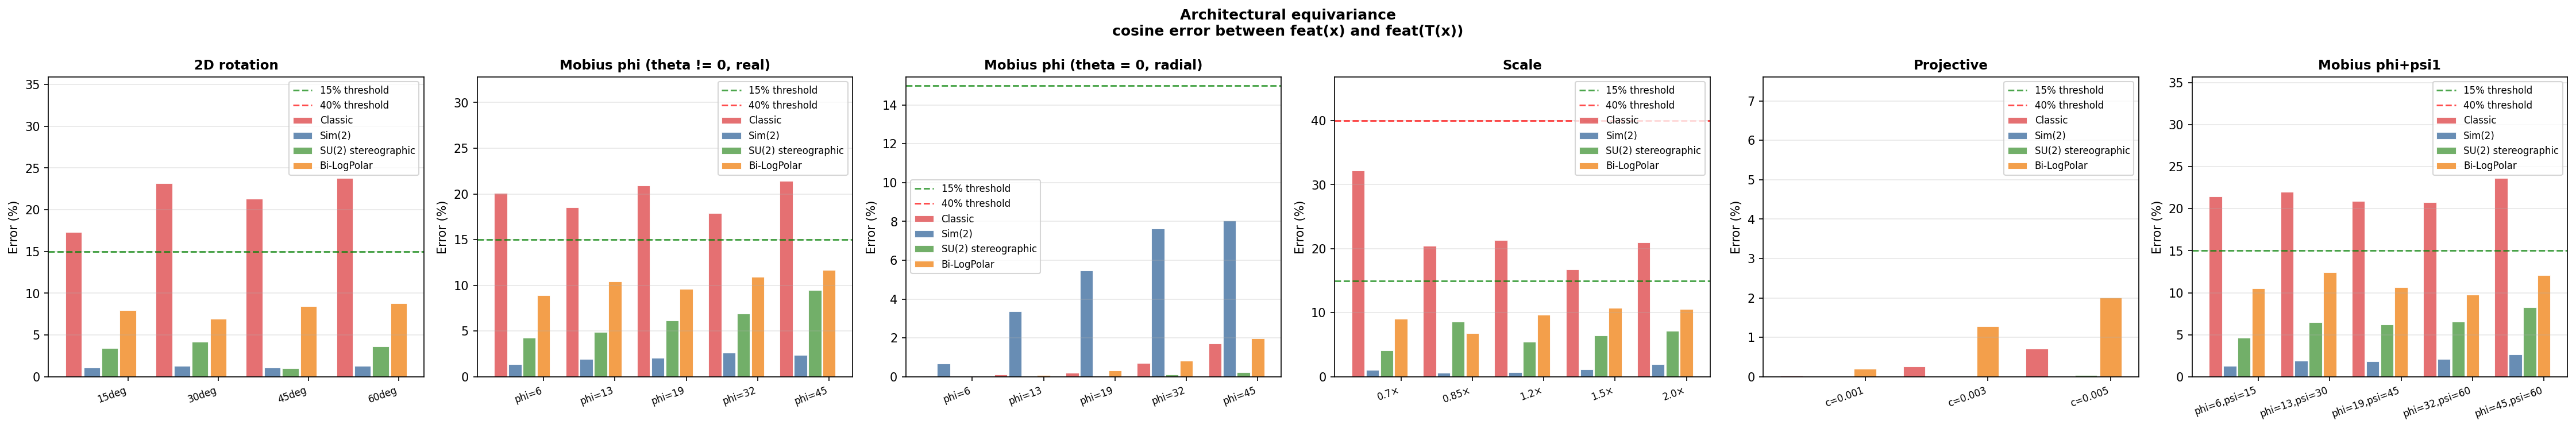


-- Trained weights --

════════════════════════════════════════════════════════════════════════════════
  ARCHITECTURAL EQUIVARIANCE
  cosine error (< 10% is good)
════════════════════════════════════════════════════════════════════════════════

  ── 2D ROTATION ──
  Transformation             Classic        Sim(2)  SU(2) stereographic   Bi-LogPolar
  ----------------------------------------------------------------------------
  15deg                      8.9% ✅      13.1% ✅      13.1% ✅      24.7% ⚠️ 
  30deg                      9.3% ✅      17.2% ⚠️       17.9% ⚠️       32.0% ⚠️ 
  45deg                     10.8% ✅      14.5% ✅       9.3% ✅      26.2% ⚠️ 
  60deg                     10.0% ✅      23.7% ⚠️       13.8% ✅      27.5% ⚠️ 
  Mean                        9.8%          17.1%          13.5%          27.6%   

  ── MOBIUS PHI (THETA != 0, REAL) ──
  Transformation             Classic        Sim(2)  SU(2) stereographic   Bi-LogPolar
  --------------------------------------------

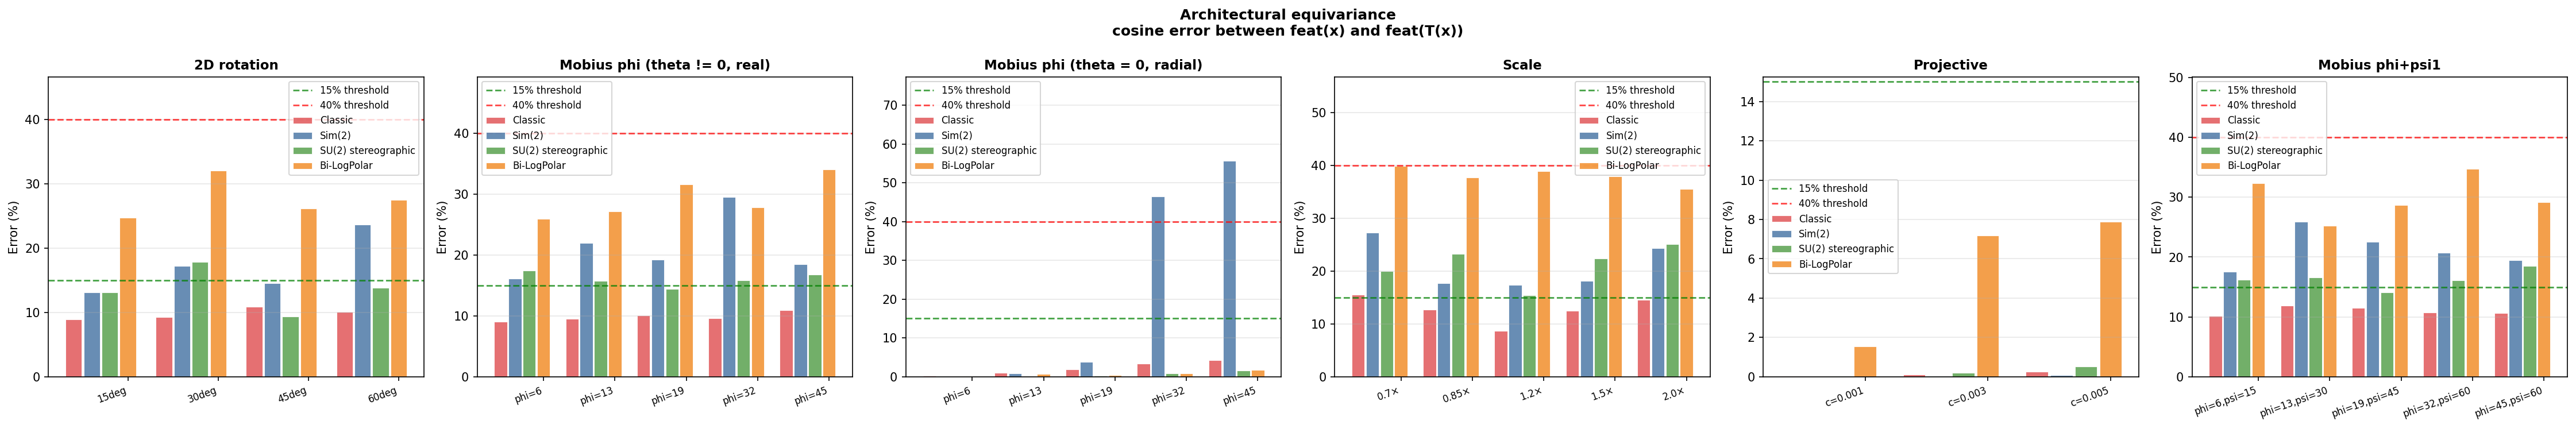

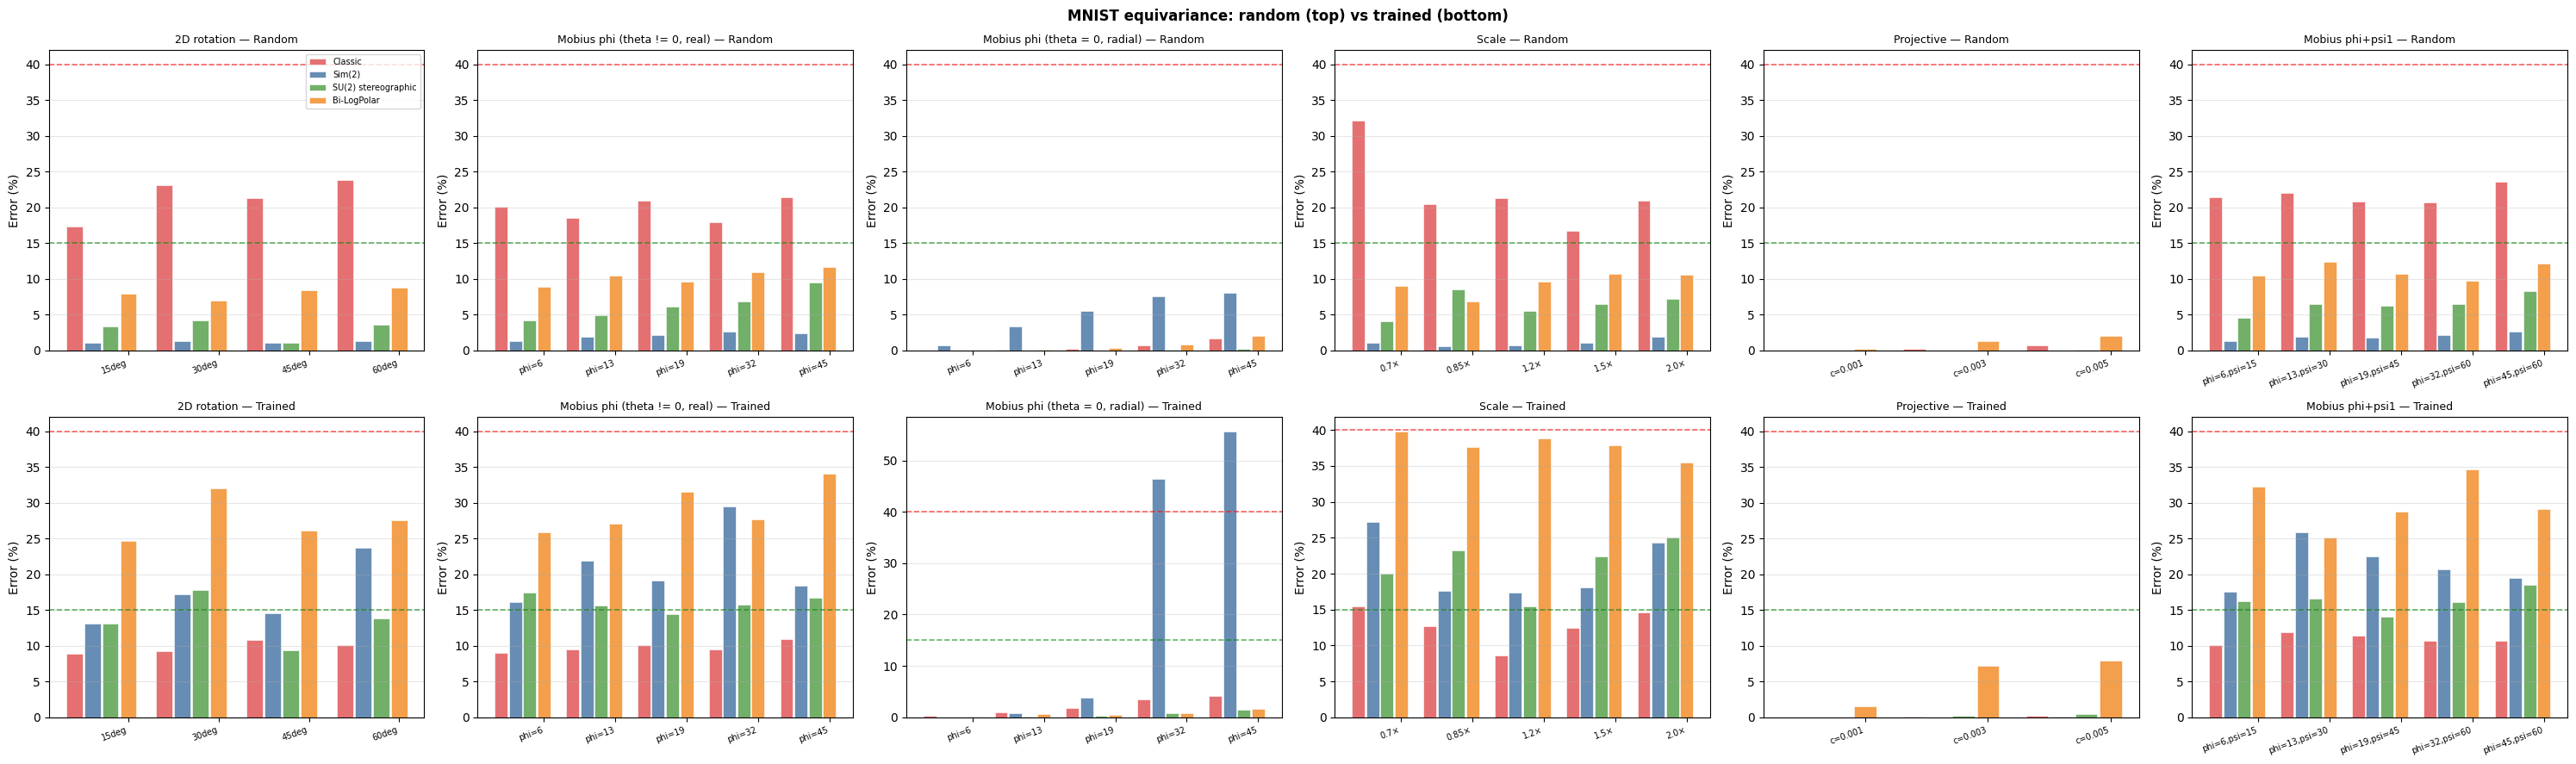

💾 ./reviewer_outputs/equivariance_comparison.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE B - Architectural equivariance (equivariance figure of the paper)
#
#  Two regimes:
#    * random weights   -> equivariance comes from the architecture alone
#    * trained weights  -> it survives optimisation
# ══════════════════════════════════════════════════════════════════════════════
seed_everything()
x_test   = torch.randn(8, 1, 28, 28, device=device)
x_radial = make_radial_images(8, size=28, device=device)

transforms_dict = {
    "2D rotation": [
        ("15deg", lambda x: apply_rotation_2d(x, 15)),
        ("30deg", lambda x: apply_rotation_2d(x, 30)),
        ("45deg", lambda x: apply_rotation_2d(x, 45)),
        ("60deg", lambda x: apply_rotation_2d(x, 60)),
    ],
    "Mobius phi (theta != 0, real)": [
        ("phi=6",  lambda x: apply_mobius_phi(x, math.radians(6))),
        ("phi=13", lambda x: apply_mobius_phi(x, math.radians(13))),
        ("phi=19", lambda x: apply_mobius_phi(x, math.radians(19))),
        ("phi=32", lambda x: apply_mobius_phi(x, math.radians(32))),
        ("phi=45", lambda x: apply_mobius_phi(x, math.radians(45))),
    ],
    "Mobius phi (theta = 0, radial)": [
        ("phi=6",  lambda x: apply_mobius_phi(x, math.radians(6))),
        ("phi=13", lambda x: apply_mobius_phi(x, math.radians(13))),
        ("phi=19", lambda x: apply_mobius_phi(x, math.radians(19))),
        ("phi=32", lambda x: apply_mobius_phi(x, math.radians(32))),
        ("phi=45", lambda x: apply_mobius_phi(x, math.radians(45))),
    ],
    "Scale": [
        ("0.7×",  lambda x: apply_scale(x, 0.7)),
        ("0.85×", lambda x: apply_scale(x, 0.85)),
        ("1.2×",  lambda x: apply_scale(x, 1.2)),
        ("1.5×",  lambda x: apply_scale(x, 1.5)),
        ("2.0×",  lambda x: apply_scale(x, 2.0)),
    ],
    "Projective": [
        ("c=0.001", lambda x: apply_projective(x, 0.001, 0.001)),
        ("c=0.003", lambda x: apply_projective(x, 0.003, 0.003)),
        ("c=0.005", lambda x: apply_projective(x, 0.005, 0.005)),
    ],
    "Mobius phi+psi1": [
        ("phi=6,psi=15",  lambda x: apply_mobius_combo(x, math.radians(6),  math.radians(15))),
        ("phi=13,psi=30", lambda x: apply_mobius_combo(x, math.radians(13), math.radians(30))),
        ("phi=19,psi=45", lambda x: apply_mobius_combo(x, math.radians(19), math.radians(45))),
        ("phi=32,psi=60", lambda x: apply_mobius_combo(x, math.radians(32), math.radians(60))),
        ("phi=45,psi=60", lambda x: apply_mobius_combo(x, math.radians(45), math.radians(60))),
    ],
}
x_per_family = {"Mobius phi (theta = 0, radial)": x_radial}

# -- B.1 - random weights ----------------------------------------------------
eq_random_path = os.path.join(CKPT_DIR, "equivariance_random.json")
if random_models:
    print("-- Weights at initialisation --")
    eq_results = measure_equivariance(random_models, x_test, transforms_dict, x_per_family)
elif os.path.exists(eq_random_path):
    print("-- Weights at initialisation: values read back from the repo --")
    with open(eq_random_path) as f:
        raw = json.load(f)
    eq_results = {t: {fam: [(l, e) for l, e in steps] for fam, steps in fams.items()}
                  for t, fams in raw.items()}
else:
    eq_results = None
    print("No initialisation reference available -> B.1 skipped.")

if eq_results is not None:
    print_equivariance_table(eq_results)
    plot_equivariance(eq_results, OUT_DIR, suffix="_random")
    show_png(os.path.join(OUT_DIR, "equivariance_random.png"))
    equivariance_to_dataframe(eq_results).to_csv(
        os.path.join(OUT_DIR, "equivariance_random.csv"), index=False)

# -- B.2 - trained weights ---------------------------------------------------
print("\n-- Trained weights --")
eq_trained = measure_equivariance(trained_models, x_test, transforms_dict, x_per_family)
print_equivariance_table(eq_trained)
plot_equivariance(eq_trained, OUT_DIR, suffix="_trained")
show_png(os.path.join(OUT_DIR, "equivariance_trained.png"))
equivariance_to_dataframe(eq_trained).to_csv(
    os.path.join(OUT_DIR, "equivariance_trained.csv"), index=False)

# -- B.3 - side-by-side figure (random vs trained) ---------------------------
if eq_results is not None:
    tags_eq = [t for t in TAGS if t in eq_results and t in eq_trained]
    fig, axes = plt.subplots(2, len(transforms_dict),
                             figsize=(5 * len(transforms_dict), 9), squeeze=False)
    fig.suptitle("MNIST equivariance: random (top) vs trained (bottom)",
                 fontsize=12, fontweight='bold')
    for col, t_name in enumerate(transforms_dict.keys()):
        for row, (res, title) in enumerate([(eq_results, "Random"),
                                            (eq_trained, "Trained")]):
            ax = axes[row, col]
            n_s = len(res[tags_eq[0]][t_name])
            xpos = np.arange(n_s)
            bw = 0.8 / len(tags_eq)
            xlbl = [l for l, _ in res[tags_eq[0]][t_name]]
            for ti, tag in enumerate(tags_eq):
                errs = [e for _, e in res[tag][t_name]]
                ax.bar(xpos + ti * bw - 0.4 + bw / 2, errs, bw * 0.9,
                       color=MODEL_COLORS.get(tag, 'gray'), alpha=0.85,
                       label=MODEL_LABELS.get(tag, tag), edgecolor='white', lw=0.5)
            ax.axhline(15., color='green', ls='--', lw=1.2, alpha=0.6)
            ax.axhline(40., color='red',   ls='--', lw=1.2, alpha=0.6)
            ax.set_xticks(xpos + 0.4 - bw / 2)
            ax.set_xticklabels(xlbl, fontsize=7, rotation=20, ha='right')
            ax.set_title(f"{t_name} — {title}", fontsize=9)
            ax.set_ylabel('Error (%)')
            ax.grid(True, alpha=0.3, axis='y')
            if row == 0 and col == 0:
                ax.legend(fontsize=7)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, "equivariance_comparison.png")
    plt.savefig(p, dpi=150, bbox_inches='tight')
    display(fig)
    plt.close(fig)
    print(f"💾 {p}")

---
## Phase C - Applied transformations

Control panels: they make it possible to check visually that the tested amplitudes stay semantically valid, i.e. that a 6 does not turn into a 9.

✅ Grilles : φ=20 | ψ₁=20 | scale=7 | proj=40 | combo=20 | SU(2)=32
   -> 139 forward passes per batch and per model (43,924 in total)


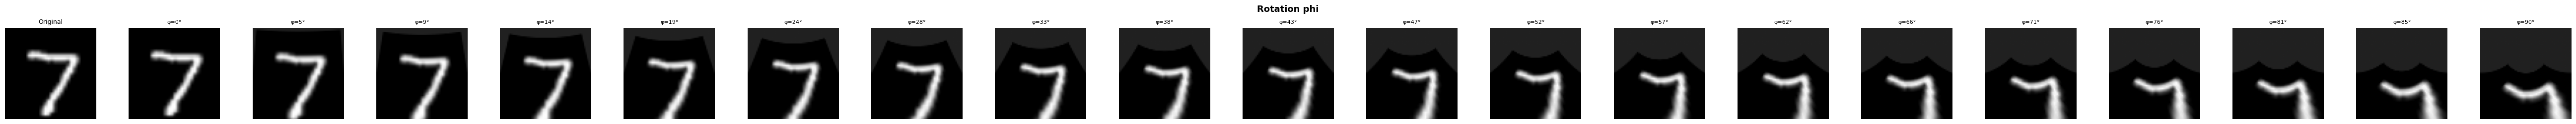

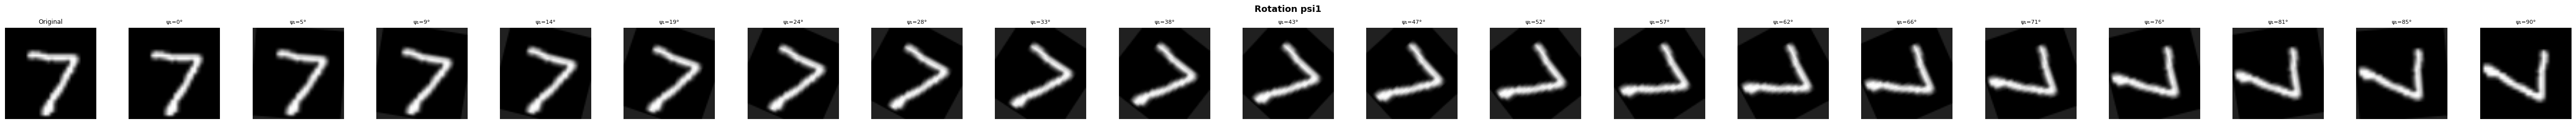

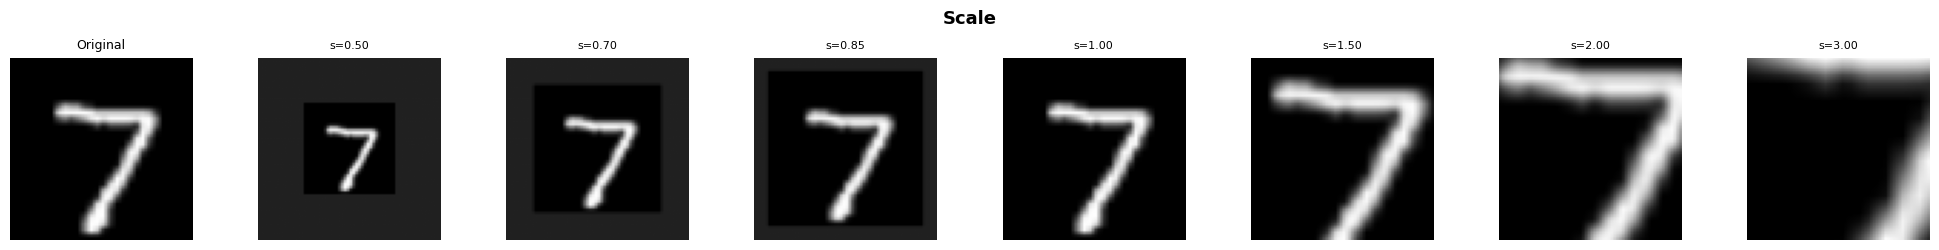

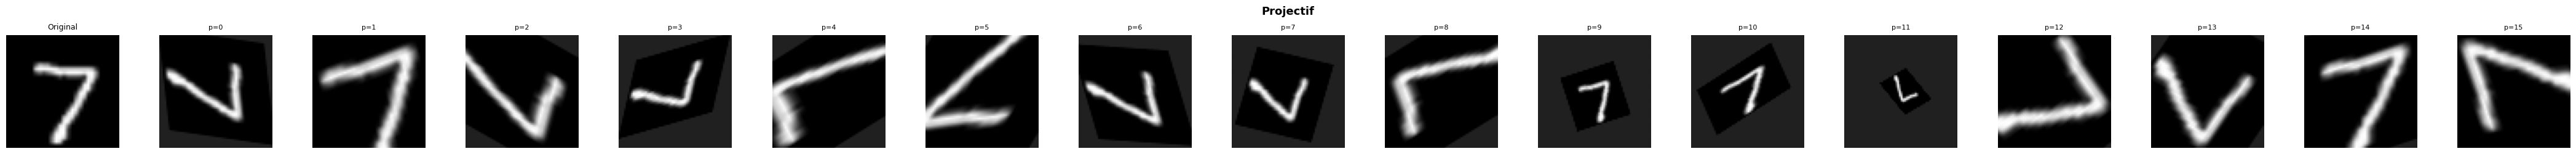

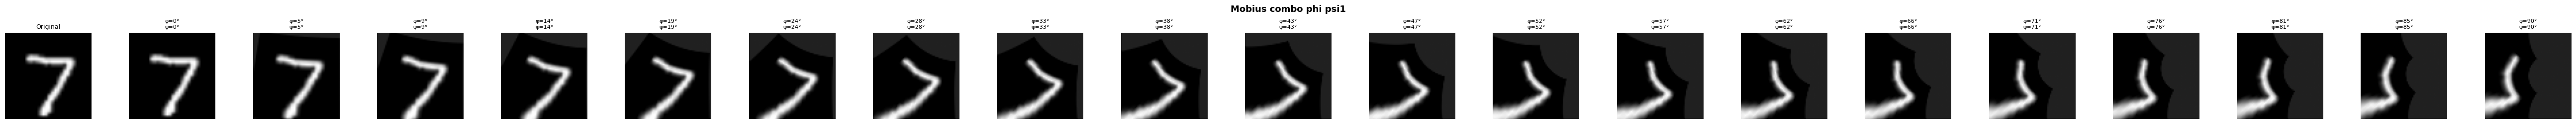

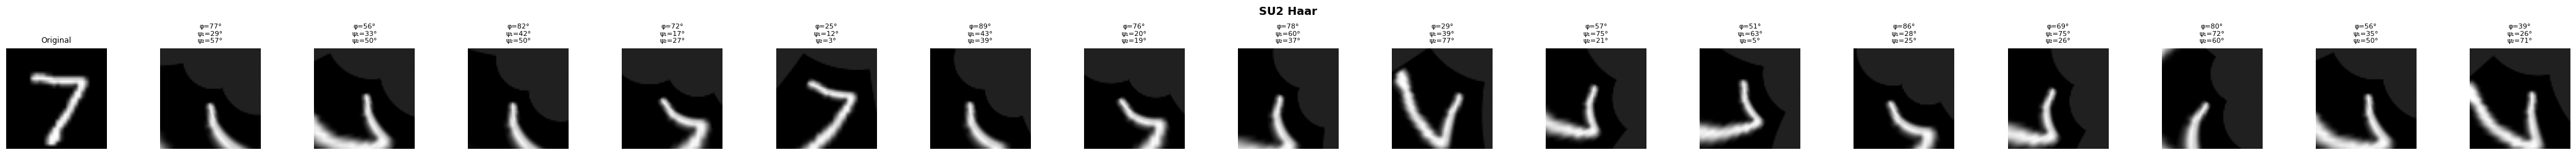

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE C — Construction des familles de transformations (grilles de sweep)
#
#  phi  : radial SU(2) Mobius,     0 -> 90 deg
#  psi1 : planar S1 rotation,      0 -> 90 deg
#  Scale: uniform scaling 0.5x -> 3x
#  Proj : random homographies (seed 42)
#  Combo: phi and psi1 increasing jointly
#  SU(2): sampled from the Haar measure (seed 42); 6 <-> 9 excluded by design
# ══════════════════════════════════════════════════════════════════════════════
seed_everything()
lin     = torch.linspace(-1, 1, IMG_SIZE, device=device)
grid_r2 = torch.stack(torch.meshgrid(lin, lin, indexing='xy'))

phi_values_rad = np.linspace(0, math.pi / 2, CFG['n_phi'])
phi_grids      = _build_phi_grids_manual(phi_values_rad, grid_r2)

psi1_rad, psi1_deg, psi1_grids = _build_psi1_grids(CFG['n_psi1'], grid_r2,
                                                   phi_fixed=0., max_deg=90.)

SWEEP_SCALE = [0.5, 0.7, 0.85, 1.0, 1.5, 2.0, 3.0]
scale_grids, scale_arr = _build_scale_grids(SWEEP_SCALE, IMG_SIZE, IMG_SIZE, device)

proj_grids = _build_projective_grids(CFG['n_proj'], IMG_SIZE, IMG_SIZE, device,
                                     seed=42, mnist_safe=False)

N_COMBO        = CFG['n_combo']
phi_combo_rad  = np.linspace(0, math.pi / 2, N_COMBO)
psi1_combo_rad = np.linspace(0, math.pi / 2, N_COMBO)
combo_grids    = _build_combo_grids(phi_combo_rad, psi1_combo_rad, grid_r2)

su2_grids, phi_su2, psi1_su2, psi2_su2 = _build_su2_random_grids(
    n_samples = CFG['n_su2'],
    grid_r2   = grid_r2,
    max_phi   = math.pi / 2,
    max_psi1  = math.pi / 2,
    max_psi2  = math.pi / 2,
    seed      = 42,
)

phi_labels   = [f"φ={math.degrees(v):.0f}°" for v in phi_values_rad]
psi1_labels  = [f"ψ₁={d:.0f}°"              for d in psi1_deg]
scale_labels = [f"s={v:.2f}"                for v in SWEEP_SCALE]
proj_labels  = [f"p={i}"                    for i in range(len(proj_grids))]
combo_labels = [f"φ={math.degrees(p):.0f}°\nψ={math.degrees(s):.0f}°"
                for p, s in zip(phi_combo_rad, psi1_combo_rad)]
su2_labels   = [f"φ={math.degrees(phi_su2[i]):.0f}°\n"
                f"ψ₁={math.degrees(psi1_su2[i]):.0f}°\n"
                f"ψ₂={math.degrees(psi2_su2[i]):.0f}°"
                for i in range(len(phi_su2))]

print(f"✅ Grilles : φ={len(phi_grids)} | ψ₁={len(psi1_grids)} | "
      f"scale={len(scale_grids)} | proj={len(proj_grids)} | "
      f"combo={len(combo_grids)} | SU(2)={len(su2_grids)}")
n_fwd = (len(phi_grids) + len(psi1_grids) + len(scale_grids) + len(proj_grids)
         + len(combo_grids) + len(su2_grids))
print(f"   -> {n_fwd} forward passes per batch and per model "
      f"({n_fwd * len(val_loader) * len(TAGS):,} in total)")

# -- Control panels: what the transformed images actually look like ----------
VISU_MAX = 16
visualize_transformations(
    val_loader,
    phi_grids    = phi_grids,
    psi1_grids   = psi1_grids,
    scale_grids  = scale_grids,
    proj_grids   = proj_grids[:VISU_MAX],
    combo_grids  = combo_grids,
    su2_grids    = su2_grids[:VISU_MAX],
    phi_labels   = phi_labels,
    psi1_labels  = psi1_labels,
    scale_labels = scale_labels,
    proj_labels  = proj_labels[:VISU_MAX],
    combo_labels = combo_labels,
    su2_labels   = su2_labels[:VISU_MAX],
    save_dir     = OUT_DIR,
    dataset      = 'mnist',
)

---
## Phase D - Robustness sweeps

**Longest cell.** This is the central result of the paper: accuracy as a function of transformation amplitude, for six families.

  Sweep [Classic]:   0%|          | 0/79 [00:00<?, ?it/s]

  [Classic] ΔΦ=+86.61% | Δψ₁=+79.58% | Scale Δ=71.72% | Proj 35.5%±24.0%  (excl. 1,9) | Combo Δ=+96.51% | SU(2) μ=13.5% σ=17.3% min=3.3%


  Sweep [Sim2Only]:   0%|          | 0/79 [00:00<?, ?it/s]

  [Sim2Only] ΔΦ=+90.99% | Δψ₁=+20.88% | Scale Δ=77.34% | Proj 71.9%±14.0%  (excl. 1,9) | Combo Δ=+92.48% | SU(2) μ=25.3% σ=23.7% min=7.0%


  Sweep [SU2Stereo]:   0%|          | 0/79 [00:00<?, ?it/s]

  [SU2Stereo] ΔΦ=+52.19% | Δψ₁=+0.00% | Scale Δ=85.74% | Proj 60.5%±26.3%  (excl. 1,9) | Combo Δ=+52.19% | SU(2) μ=52.2% σ=13.7% min=37.8%


  Sweep [BiLogPolar]:   0%|          | 0/79 [00:00<?, ?it/s]

  [BiLogPolar] ΔΦ=+89.84% | Δψ₁=+31.77% | Scale Δ=78.07% | Proj 55.1%±21.4%  (excl. 1,9) | Combo Δ=+91.79% | SU(2) μ=15.6% σ=18.8% min=4.7%

Sweep finished in 8.8 min

📊 Robustness tables saved:
   💾 ./reviewer_outputs/rob_sweep_phi.csv
   💾 ./reviewer_outputs/rob_sweep_psi1.csv
   💾 ./reviewer_outputs/rob_sweep_scale.csv
   💾 ./reviewer_outputs/rob_sweep_proj.csv
   💾 ./reviewer_outputs/rob_sweep_combo.csv
   💾 ./reviewer_outputs/rob_sweep_su2.csv
   💾 ./reviewer_outputs/rob_summary.csv

-- Summary --
              model  phi_at_0  phi_drop  psi1_at_0  psi1_drop  scale_at_1  scale_range  proj_mean  proj_std  combo_at_0  combo_drop  su2_mean  su2_std  su2_min
            Classic     99.54     86.61      99.54      79.58       99.54        71.72      35.46     23.95       99.54       96.51     13.47    17.28     3.35
             Sim(2)     99.38     90.99      99.38      20.88       99.38        77.34      71.90     14.01       99.38       92.48     25.29    23.73     7.03
SU(2) stereo

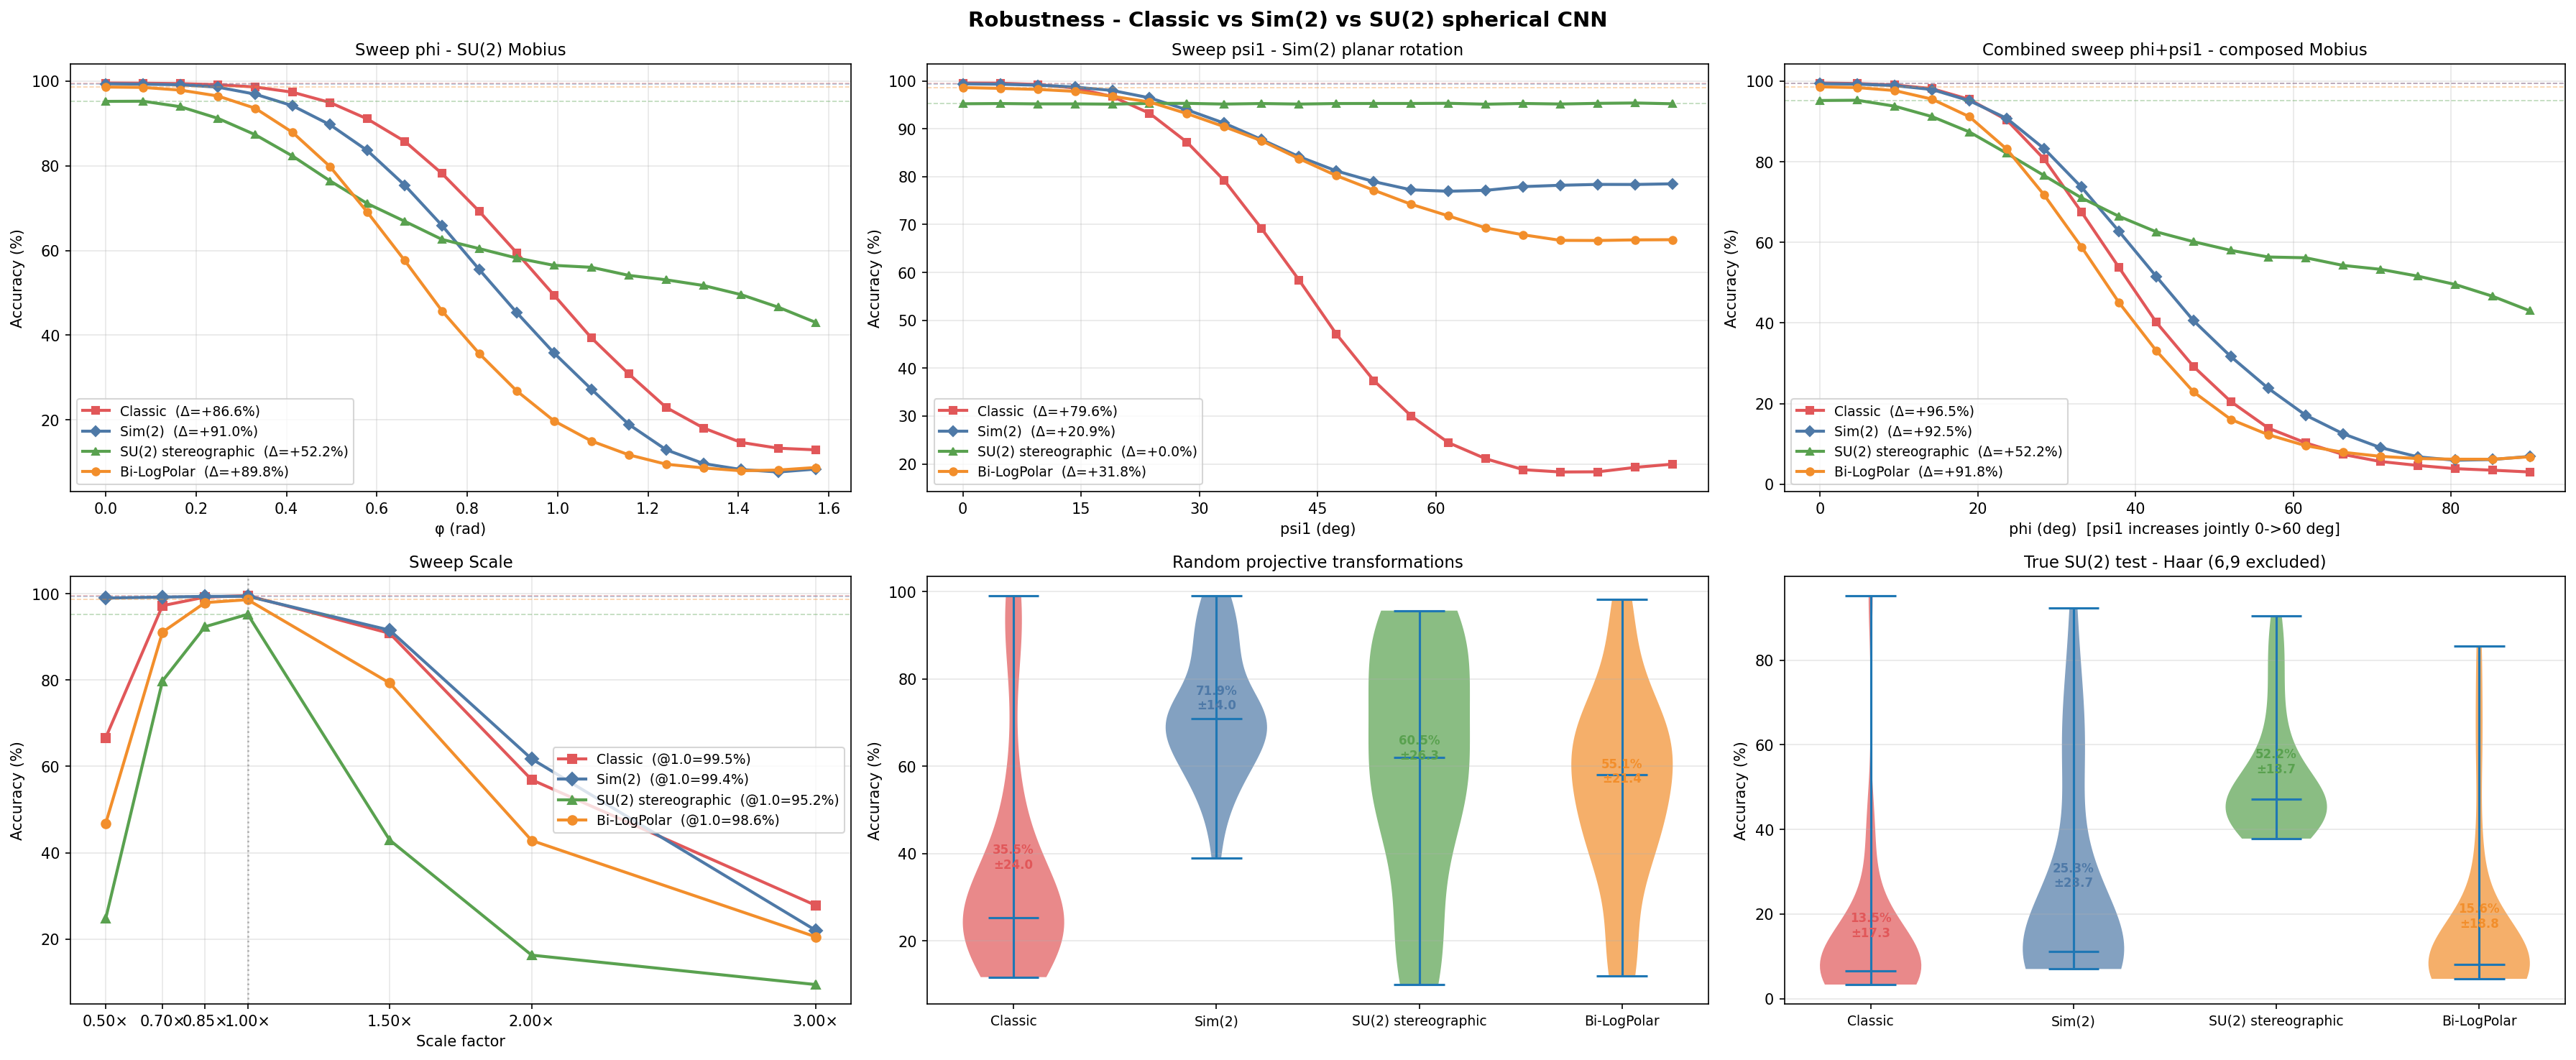

💾 ./reviewer_outputs/robustness_raw.json


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE D - Robustness sweeps (the paper's central result)
#
#  For each transformation family and each amplitude, top-1 accuracy is
#  measured on the test set. What matters is not the absolute value but the
#  DROP between zero and maximum amplitude: a drop near 0 means invariance.
#
#  This is the longest cell. 'quick' mode ~3-5 min, 'full' mode ~30-45 min
#  on a T4.
# ══════════════════════════════════════════════════════════════════════════════
seed_everything()
t0 = time.time()

rob_results = sweep_all_models(
    trained_models, val_loader,
    phi_grids, psi1_grids, scale_grids, proj_grids,
    combo_grids = combo_grids,
    su2_grids   = su2_grids,
)

print(f"\nSweep finished in {(time.time()-t0)/60:.1f} min")

save_robustness_tables(
    rob_results, phi_values_rad, psi1_deg, scale_arr,
    phi_combo_rad  = phi_combo_rad,
    psi1_combo_rad = psi1_combo_rad,
    save_dir       = OUT_DIR,
)

print_robustness_table(phi_values_rad, psi1_deg, scale_arr, rob_results,
                       phi_combo_rad  = phi_combo_rad,
                       psi1_combo_rad = psi1_combo_rad)

plot_robustness_curves(phi_values_rad, psi1_deg, scale_arr, rob_results, OUT_DIR,
                       phi_combo_rad  = phi_combo_rad,
                       psi1_combo_rad = psi1_combo_rad)
show_png(os.path.join(OUT_DIR, "robustness_curves.png"), width=1400)

# -- Raw dump for re-analysis outside the notebook ---------------------------
with open(os.path.join(OUT_DIR, "robustness_raw.json"), "w") as f:
    json.dump({t: {k: np.asarray(v).tolist() for k, v in e.items()}
               for t, e in rob_results.items()}, f, indent=2)
print(f"💾 {os.path.join(OUT_DIR, 'robustness_raw.json')}")

---
## Phase E - Training curves

Replotted from `history.csv`, recorded during the original training run. Nothing is retrained.

,Model,Epoch,Train_Loss,Train_Acc,Val_Acc
0,Classic,1,1.672294,49.505000,89.51
1,Classic,2,0.229443,94.380000,97.88
2,Classic,3,0.087188,97.488333,97.06
3,Classic,4,0.070911,97.900000,98.28
4,Classic,5,0.048262,98.580000,99.05


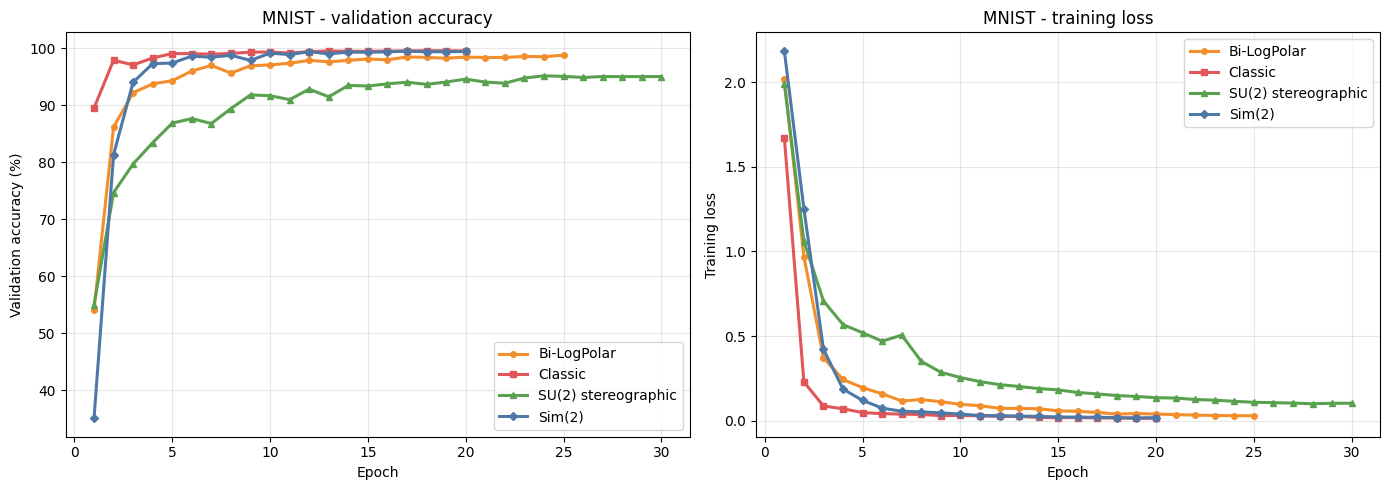

,Model name,Best val acc (%)
0,Bi-LogPolar,98.77
1,Classic,99.55
2,SU(2) stereographic,95.15
3,Sim(2),99.47


,Model,Epochs,lr,weight_decay,batch,accum,width_mult,Params
0,Classic,20,0.0005,0.0001,128,1,0.277344,498219
1,Sim(2),20,0.0005,0.0001,128,1,0.246094,511135
2,SU(2) stereographic,30,0.0006,0.0050,512,1,0.572917,503012
3,Bi-LogPolar,25,0.0004,0.0001,128,1,0.273437,489949


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE E - Training curves
#
#  Nothing is retrained. The per-epoch history was recorded during the
#  original training run and ships with the weights (history.csv). This cell
#  only replots it.
# ══════════════════════════════════════════════════════════════════════════════
hist_path = os.path.join(CKPT_DIR, MANIFEST.get("history", "history.csv"))

if os.path.exists(hist_path):
    df_hist = pd.read_csv(hist_path)
    display(df_hist.head())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for tag, grp in df_hist.groupby('Model'):
        axes[0].plot(grp['Epoch'], grp['Val_Acc'],
                     color=MODEL_COLORS.get(tag, 'gray'),
                     marker=MODEL_MARKERS.get(tag, 'o'), ms=4, lw=2.2,
                     label=MODEL_LABELS.get(tag, tag))
        axes[1].plot(grp['Epoch'], grp['Train_Loss'],
                     color=MODEL_COLORS.get(tag, 'gray'),
                     marker=MODEL_MARKERS.get(tag, 'o'), ms=4, lw=2.2,
                     label=MODEL_LABELS.get(tag, tag))
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation accuracy (%)')
    axes[0].set_title('MNIST - validation accuracy'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Training loss')
    axes[1].set_title('MNIST - training loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, "training_curves.png")
    plt.savefig(p, dpi=150, bbox_inches='tight')
    display(fig); plt.close(fig)

    best = (df_hist.groupby('Model')['Val_Acc'].max()
            .rename('Best val acc (%)').reset_index())
    best['Model name'] = best['Model'].map(lambda t: MODEL_LABELS.get(t, t))
    display(best[['Model name', 'Best val acc (%)']])
    df_hist.to_csv(os.path.join(OUT_DIR, "history.csv"), index=False)
else:
    print(f"{hist_path} not found - the training history was not shipped with "
          f"the weights. Other phases are unaffected.")

# -- Declared training hyper-parameters (for the reproducibility section) ----
hp_rows = []
for tag, info in MANIFEST.get("models", {}).items():
    hp = info.get("train_hparams", {})
    hp_rows.append({'Model': MODEL_LABELS.get(tag, tag),
                    'Epochs': info.get('epochs'),
                    'lr': hp.get('lr'), 'weight_decay': hp.get('weight_decay'),
                    'batch': hp.get('batch_size'), 'accum': hp.get('accum'),
                    'width_mult': info.get('width_mult'),
                    'Params': info.get('params')})
if hp_rows:
    df_hp = pd.DataFrame(hp_rows)
    display(df_hp)
    df_hp.to_csv(os.path.join(OUT_DIR, "train_hparams.csv"), index=False)

---
## Phase F - Summary

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  PHASE F - Summary table and results archive
# ══════════════════════════════════════════════════════════════════════════════
idx_sc = int(np.argmin(np.abs(scale_arr - 1.0)))
summary = []
for tag in TAGS:
    r  = rob_results[tag]
    pa, sa, sca, pra = r['phi'], r['psi1'], r['scale'], r['proj']
    row = {
        'Model':    MODEL_LABELS.get(tag, tag),
        'Acc (%)':  float(df_clean.loc[df_clean['Model'] == MODEL_LABELS.get(tag, tag),
                                       'Acc (%)'].iloc[0]),
        'ΔΦ':       float(pa[0] - pa[-1]),
        'Δψ₁':      float(sa[0] - sa[-1]),
        'ΔScale':   float(sca.max() - sca.min()),
        'Proj μ':   float(pra.mean()),
    }
    if 'combo' in r:
        row['ΔCombo'] = float(r['combo'][0] - r['combo'][-1])
    if 'su2' in r:
        row['SU(2) μ']   = float(r['su2'].mean())
        row['SU(2) min'] = float(r['su2'].min())
    summary.append(row)

df_final = pd.DataFrame(summary)
df_final.to_csv(os.path.join(OUT_DIR, "reviewer_summary.csv"), index=False)
display(df_final.style.format({c: '{:.2f}' for c in df_final.columns if c != 'Model'}))

print("\nReading: delta = accuracy drop between zero and maximum amplitude.")
print("Close to 0 means invariance; large means the model depends on pose.")
print("Classes 1 and 9 are excluded from the sweeps (6 <-> 9 ambiguity under")
print("rotation), as in the paper, so sweep accuracies are not directly")
print("comparable to the ten-class figures of Phase A.")

# ── Archive ─────────────────────────────────────────────────────────────────
zip_path = os.path.join(OUT_DIR, "reviewer_results.zip")
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(OUT_DIR):
        for fn in files:
            if fn.endswith('.zip'):
                continue
            fp = os.path.join(root, fn)
            z.write(fp, os.path.relpath(fp, OUT_DIR))
print(f"\nArchive: {zip_path}")

produced = sorted(f for f in os.listdir(OUT_DIR) if not f.endswith('.zip'))
print(f"\n{len(produced)} files produced:")
for f in produced:
    print(f"   • {f}")

try:
    from google.colab import files as colab_files
    print("\nRun  colab_files.download(zip_path)  to download the archive.")
except ImportError:
    pass

print(f"\nReproduction complete - mode '{RUN_MODE}', transform '{EVAL_TRANSFORM}'.")

,Model,Acc (%),ΔΦ,Δψ₁,ΔScale,Proj μ,ΔCombo,SU(2) μ,SU(2) min
0,Classic,99.55,86.61,79.58,71.72,35.46,96.51,13.47,3.35
1,Sim(2),99.33,90.99,20.88,77.34,71.90,92.48,25.29,7.03
2,SU(2) stereographic,94.73,52.19,0.00,85.74,60.51,52.19,52.22,37.84
3,Bi-LogPolar,98.61,89.84,31.77,78.07,55.12,91.79,15.64,4.70



Reading: delta = accuracy drop between zero and maximum amplitude.
Close to 0 means invariance; large means the model depends on pose.
Classes 1 and 9 are excluded from the sweeps (6 <-> 9 ambiguity under
rotation), as in the paper, so sweep accuracies are not directly
comparable to the ten-class figures of Phase A.

Archive: ./reviewer_outputs/reviewer_results.zip

25 files produced:
   • equivariance_comparison.png
   • equivariance_random.csv
   • equivariance_random.png
   • equivariance_trained.csv
   • equivariance_trained.png
   • history.csv
   • reviewer_summary.csv
   • rob_summary.csv
   • rob_sweep_combo.csv
   • rob_sweep_phi.csv
   • rob_sweep_proj.csv
   • rob_sweep_psi1.csv
   • rob_sweep_scale.csv
   • rob_sweep_su2.csv
   • robustness_curves.png
   • robustness_raw.json
   • table1_clean_accuracy.csv
   • train_hparams.csv
   • training_curves.png
   • transforms_Mobius_combo_phi_psi1.png
   • transforms_Projectif.png
   • transforms_Rotation_phi.png
   • transforms_